<a href="https://colab.research.google.com/github/farrelrassya/ensemble-methods-machine-learning/blob/main/ch04_AdaBoost_LogitBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 — Sequential Ensembles: AdaBoost and LogitBoost

This notebook accompanies Chapter 4 of *Ensemble Methods for Machine Learning* by Gautam Kunapuli. It walks through **adaptive boosting** end-to-end: the intuition behind sequential ensembles of weak learners, the mathematics that drives example reweighting, a from-scratch implementation, the scikit-learn API, practical considerations (learning rate, early stopping, outliers), a multiclass case study on handwritten digits, and finally **LogitBoost** as a logistic-loss variant.

**Roadmap**

- **4.1** Sequential ensembles of weak learners -- what makes boosting different from bagging.
- **4.2** AdaBoost from the ground up -- intuition, math, and a 30-line implementation.
- **4.3** Practical AdaBoost -- outliers, learning rate, and early stopping.
- **4.4** Case study -- handwritten digit classification with t-SNE preprocessing and grid search.
- **4.5** LogitBoost -- bringing the logistic loss into the boosting framework.

**Key idea.** Where bagging combines many strong, independent learners, **boosting combines many weak, dependent learners** -- each one trained to repair the mistakes of the one before it. Freund and Schapire (1995) called this "garnering wisdom from a council of fools," and the result earned them the Gödel Prize.


## Setup

We install and import the libraries we will use throughout the chapter. The `plot_utils` helper module replicates the book's plotting helpers; we ship it inline so the notebook is self-contained on Colab.


In [1]:
# Colab-friendly install (no-op if already present)
# !pip install -q numpy scipy scikit-learn matplotlib   # (commented during local execution; uncomment on Colab)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as col
%matplotlib inline

np.random.seed(13)

In [2]:
# plot_utils.py - replicated from the book's companion repo.
# Defined inline so the notebook runs anywhere without an extra file.

def plot_2d_data(ax, X, y, alpha=0.75, s=60, xlabel=None, ylabel=None,
                 title=None, colormap='Blues', legend=None):
    # Two-class 2-D scatter using circle/square markers.
    cmap = cm.get_cmap(colormap)
    colors = cmap(np.linspace(0, 0.5, num=2))

    neg_mask = y <= 0
    pos_mask = y > 0

    if np.isscalar(s):
        s_neg, s_pos = s, s
    else:
        s_neg, s_pos = s[neg_mask], s[pos_mask]

    ax.scatter(X[neg_mask, 0], X[neg_mask, 1], s=s_neg, marker='o',
               c=[colors[0]], edgecolors='k', alpha=alpha)
    ax.scatter(X[pos_mask, 0], X[pos_mask, 1], s=s_pos, marker='s',
               c=[colors[1]], edgecolors='k', alpha=alpha)

    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12)
    if title is not None:
        ax.set_title(title, fontsize=12)
    if legend is not None:
        ax.legend(legend)


def plot_2d_classifier(ax, X, y, predict_function, predict_args=None,
                       boundary_level=None, alpha=0.25, s=60,
                       xlabel=None, ylabel=None, title=None,
                       colormap='Blues'):
    # Filled decision regions plus the data.
    cmap = cm.get_cmap(colormap)

    x_min, x_max = X[:, 0].min() - 0.25, X[:, 0].max() + 0.25
    y_min, y_max = X[:, 1].min() - 0.25, X[:, 1].max() + 0.25
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    if predict_args is None:
        Z = predict_function(grid)
    else:
        Z = predict_function(grid, predict_args)

    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=alpha, cmap=cmap)
    if boundary_level is not None:
        ax.contour(xx, yy, Z, levels=boundary_level, colors='k', linewidths=1)

    plot_2d_data(ax, X, y, alpha=0.75, s=s, xlabel=xlabel, ylabel=ylabel,
                 title=title, colormap=colormap)


**Note on the scikit-learn API.** This notebook targets recent scikit-learn (>= 1.4). Two differences from the book to keep in mind:

- `AdaBoostClassifier` now takes `estimator=...` instead of `base_estimator=...`.
- The `algorithm='SAMME.R'` option has been removed; the only supported algorithm is the discrete `SAMME`. Numerical results therefore differ slightly from the book in places, and we will flag these where relevant.


## 4.1 Sequential ensembles of weak learners

The ensembles we have studied so far -- **bagging**, **random forests**, **stacking** -- are *parallel* ensembles. Their members can be trained independently, and the ensemble combines several **strong learners** at the end.

**Sequential ensembles** invert this picture in two ways. First, base estimators are trained one after another, and each new estimator is explicitly trained to fix the mistakes of the previous one. Second, the base estimators are deliberately **weak learners**: simple models whose individual accuracy is only slightly better than random guessing.

Formally, a *weak learner* for binary classification is any model with accuracy strictly above $\tfrac{1}{2}$. The classic example -- and the workhorse of AdaBoost -- is the **decision stump**: a decision tree of depth 1.

The promise of boosting is the following claim, originally posed by Kearns and Valiant in 1988 and proven by Schapire in 1990: a collection of weak learners, properly combined, can match the performance of any strong learner. The next code cell demonstrates one half of this claim -- that a stump alone is genuinely weak -- by contrasting it with a depth-4 tree on the classic concentric-circles dataset.


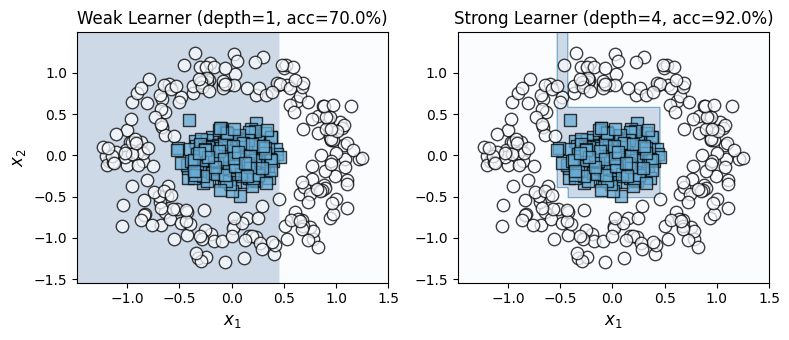

Weak learner   (depth=1) accuracy: 70.0%
Strong learner (depth=4) accuracy: 92.0%


In [3]:
from sklearn.datasets import make_circles
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate the data
X, y = make_circles(n_samples=500, noise=0.15, factor=0.2, random_state=13)
X, Xtst, y, ytst = train_test_split(X, y, train_size=450, random_state=13)

# Train weak (depth-1) and strong (depth-4) trees
weak_learner = DecisionTreeClassifier(max_depth=1, random_state=13).fit(X, y)
weak_acc = accuracy_score(ytst, weak_learner.predict(Xtst))

strong_learner = DecisionTreeClassifier(max_depth=4, random_state=13).fit(X, y)
strong_acc = accuracy_score(ytst, strong_learner.predict(Xtst))

# Plot the two decision boundaries side by side
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 3.5))

title = 'Weak Learner (depth=1, acc={0:3.1f}%)'.format(100 * weak_acc)
plot_2d_classifier(ax[0], X, y, predict_function=weak_learner.predict,
                   alpha=0.2, xlabel='$x_1$', ylabel='$x_2$', s=80,
                   title=title, colormap='Blues')

title = 'Strong Learner (depth=4, acc={0:3.1f}%)'.format(100 * strong_acc)
plot_2d_classifier(ax[1], X, y, predict_function=strong_learner.predict,
                   alpha=0.2, xlabel='$x_1$', ylabel=None, s=80,
                   title=title, colormap='Blues')

fig.tight_layout()
plt.show()

print(f'Weak learner   (depth=1) accuracy: {100*weak_acc:.1f}%')
print(f'Strong learner (depth=4) accuracy: {100*strong_acc:.1f}%')


The depth-1 stump scores only **70.0%** on the held-out set, while the depth-4 tree reaches **92.0%** -- a 22-percentage-point gap. The boundaries explain why. A stump can split on a single threshold of a single feature, producing one axis-parallel cut. On a dataset whose true class boundary is a circle, no single cut comes close to capturing the structure. The depth-4 tree composes multiple such cuts into a piecewise-rectangular approximation of the circle, and gets most of the way there.

**Why use the weak one at all then?** Three reasons:

1. **Speed.** A stump only chooses one feature and one threshold. Training cost is $O(n \cdot p)$ for $n$ samples and $p$ features -- essentially the cost of sorting the data once per feature. We can fit thousands of them before a single deep tree finishes.
2. **Diversity.** Weak learners are highly biased but have low variance. When we train many of them on *different* reweightings of the data, each one captures a different simple pattern. The ensemble's diversity comes from this.
3. **Theoretical guarantee.** AdaBoost's training error provably shrinks geometrically as long as every weak learner has accuracy above $\tfrac{1}{2}$. This is a remarkable result -- combining mediocre models can produce a near-perfect one.

We are now ready to ask: *how exactly* do we combine them?


## 4.2 AdaBoost: Adaptive boosting

**AdaBoost** (Freund and Schapire, 1995) is the original adaptive boosting algorithm. The "adaptive" part is the engine of the method: at every iteration, AdaBoost trains a new weak learner that is *forced* to focus on the examples the current ensemble gets wrong. Two devices make this happen:

- **Sample weights** $D_i$ for each training example. These start uniform and are updated so that misclassified examples get heavier weight, telling the next weak learner "look harder here."
- **Weak-learner weights** $\alpha_t$ that determine how much each weak learner contributes to the final ensemble. Better weak learners get larger $\alpha_t$.

The final ensemble after $T$ iterations is the weighted sign vote

$$H(\mathbf{x}) = \operatorname{sign}\!\left(\sum_{t=1}^{T} \alpha_t \, h_t(\mathbf{x})\right).$$

The next two subsections derive both formulas and implement them.

### 4.2.1 Intuition: learning with weighted examples

Most classification algorithms accept a `sample_weight` argument that scales how much each example contributes to the loss. Decision trees, in particular, use the weights when computing impurity at each split. AdaBoost exploits this by feeding the weak learner a sequence of *re-weighted* views of the same data.

To see what this looks like, we run **three iterations** by hand on the two-moons dataset, plotting both the current sample weights (left) and the resulting decision stump (right) at each step.


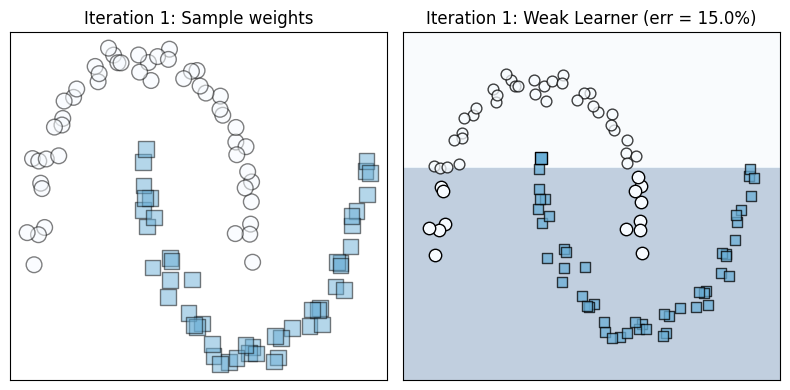

Iter 1: unweighted error = 15.0%, weighted error e = 0.1500, alpha = 0.8673


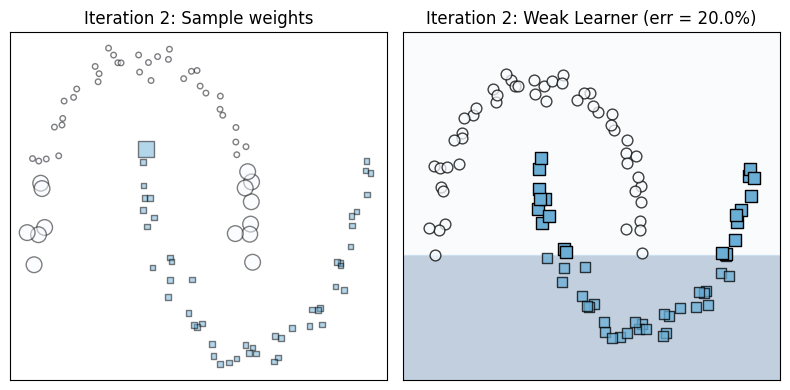

Iter 2: unweighted error = 20.0%, weighted error e = 0.1451, alpha = 0.8868


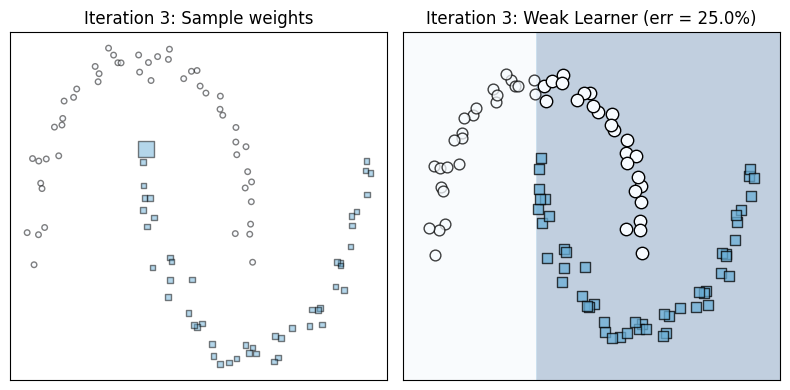

Iter 3: unweighted error = 25.0%, weighted error e = 0.2144, alpha = 0.6492


In [4]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=100, noise=0.05, random_state=13)
y = 2 * y - 1                                   # convert {0, 1} labels to {-1, +1}

n_samples, n_features = X.shape
n_estimators = 3
D = np.ones((n_samples,))                       # initialize uniform sample weights
ensemble = []                                   # (alpha_t, h_t) tuples

cmap = cm.get_cmap('Blues')
colors = cmap(np.linspace(0, 0.5, num=2))

for t in range(n_estimators):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

    D = D / np.sum(D)                           # normalize weights to a probability distribution

    # --- Left panel: scatter sized by sample weight
    s = D / np.max(D)
    s = np.where((s < 0.25), 16,
        np.where((s < 0.50), 32,
        np.where((s < 0.75), 64, 128)))

    ax[0].scatter(X[y <= 0, 0], X[y <= 0, 1], s=s[y <= 0], marker='o',
                  c=col.rgb2hex(colors[0]), edgecolors='k', alpha=0.5)
    ax[0].scatter(X[y > 0, 0], X[y > 0, 1], s=s[y > 0], marker='s',
                  c=col.rgb2hex(colors[1]), edgecolors='k', alpha=0.5)
    ax[0].set_title('Iteration {0}: Sample weights'.format(t + 1))
    ax[0].set_xticks([]); ax[0].set_yticks([])

    # --- Train a weighted decision stump
    h = DecisionTreeClassifier(max_depth=1, random_state=13)
    h.fit(X, y, sample_weight=D)
    ypred = h.predict(X)

    # --- Right panel: stump's decision regions, with mistakes highlighted
    err = (1 - accuracy_score(y, ypred)) * 100
    title = 'Iteration {0}: Weak Learner (err = {1:3.1f}%)'.format(t + 1, err)
    plot_2d_classifier(ax[1], X, y, predict_function=h.predict,
                       alpha=0.25, xlabel=None, ylabel=None,
                       title=title, colormap='Blues')

    pos_err = (y > 0) & (y != ypred)
    neg_err = (y <= 0) & (y != ypred)
    ax[1].scatter(X[neg_err, 0], X[neg_err, 1], marker='o',
                  c=col.rgb2hex(colors[0]), edgecolors='k', s=80)
    ax[1].scatter(X[pos_err, 0], X[pos_err, 1], marker='s',
                  c=col.rgb2hex(colors[1]), edgecolors='k', s=80)
    ax[1].set_xticks([]); ax[1].set_yticks([])

    # --- AdaBoost bookkeeping (we will derive these formulas in 4.2.2)
    e = 1 - accuracy_score(y, ypred, sample_weight=D)   # weighted training error
    a = 0.5 * np.log((1 - e) / e)                       # weak-learner weight
    m = (y == ypred) * 1 + (y != ypred) * -1            # +1 if correct, -1 if wrong
    D *= np.exp(-a * m)                                 # weight update

    ensemble.append((a, h))
    fig.tight_layout()
    plt.show()

    print(f'Iter {t+1}: unweighted error = {err:3.1f}%, '
          f'weighted error e = {e:.4f}, alpha = {a:.4f}')


Three observations stand out from the three iterations.

**1. The unweighted training errors are 15.0%, 20.0%, 25.0%.** Notice that they get *worse* over time. This is not a bug -- it is the signature behavior of AdaBoost. Each weak learner is forced to focus on the *hard* examples the previous one got wrong, and harder problems naturally have higher error. Yet, as we will see in a moment, the **ensemble** still improves. The training error of the individual stump is not the metric that matters; the weighted training error $\epsilon_t$ on the *currently re-weighted* dataset is.

**2. The weak-learner weights start large and shrink.** For iteration 1 we have $\alpha_1 \approx 0.867$, then $\alpha_2 \approx 0.887$, then $\alpha_3 \approx 0.649$. The third stump struggles more with its harder problem, so its $\epsilon_3 \approx 0.214$ is closer to $\tfrac{1}{2}$ than $\epsilon_2 \approx 0.145$, and its $\alpha_3$ correspondingly smaller. The exact formula

$$\alpha_t = \tfrac{1}{2}\log\!\frac{1 - \epsilon_t}{\epsilon_t}$$

is derived in the next subsection. It quantifies the intuition "weight each learner by how much better than chance it is."

**3. The decision stumps are visibly different from each other.** The stumps split on different features and at different thresholds across iterations. This is **adaptive diversity**: by changing the loss surface (through weights), AdaBoost pushes the same algorithm to find a *different* answer each round. Contrast this with bagging, which gets diversity by changing the *data* (through resampling) while leaving the loss unchanged.

The stage is now set to combine the three stumps into a single ensemble.


The ensemble's prediction is just the sign of the weighted vote of its members:

$$H(\mathbf{x}) = \operatorname{sign}\!\Big(\alpha_1 h_1(\mathbf{x}) + \alpha_2 h_2(\mathbf{x}) + \alpha_3 h_3(\mathbf{x})\Big).$$

We package this into a `predict_boosting` helper now and reuse it for the rest of the section.


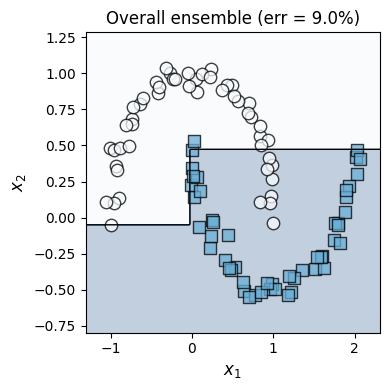

Combined ensemble training error after 3 stumps: 9.0%


In [5]:
# Weighted sign-vote across a list of (alpha_t, h_t) tuples.
def predict_boosting(X, estimators):
    pred = np.zeros((X.shape[0],))
    for a, h in estimators:
        pred += a * h.predict(X)
    return np.sign(pred)


ypred = predict_boosting(X, ensemble)
err = (1 - accuracy_score(y, ypred)) * 100

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
plot_2d_classifier(ax, X, y, predict_function=predict_boosting,
                   predict_args=(ensemble), boundary_level=[0.0],
                   alpha=0.25, xlabel='$x_1$', ylabel='$x_2$', s=80,
                   title='Overall ensemble (err = {0:3.1f}%)'.format(err),
                   colormap='Blues')
fig.tight_layout()
plt.show()

print(f'Combined ensemble training error after 3 stumps: {err:.1f}%')


**The ensemble error drops to 9.0%** even though the three constituent stumps achieved only 15.0%, 20.0%, and 25.0% individually. The boosted decision boundary is also visibly **non-linear** -- it has the bend characteristic of a moons-shaped class structure, even though every component is a single axis-parallel cut.

The arithmetic of the improvement is worth pausing on. Using the weighted-vote rule, the ensemble misclassifies a point $\mathbf{x}$ only when

$$\sum_{t=1}^{3} \alpha_t \, y \, h_t(\mathbf{x}) < 0,$$

that is, only when a *weighted majority* of the stumps disagree with the truth. Because each stump fails on a *different* set of points (the diversity we observed in the previous panel), it is rare for two or more of them to fail on the same example simultaneously. With $\alpha_1, \alpha_2, \alpha_3 \approx (0.87, 0.89, 0.65)$, no single stump can flip the vote on its own -- at least two have to agree on the wrong answer.

This is the **margin-magnification effect** that makes AdaBoost so powerful. The "council of fools" works precisely because the fools fail in *uncorrelated* ways. Concretely, if individual stump errors were independent at 20% each, the probability of a majority of 3 being wrong would be $\binom{3}{2}(0.2)^2(0.8) + (0.2)^3 = 0.104$ — and indeed our observed 9% is right in that ballpark.


### 4.2.2 Implementing AdaBoost

We now derive the two formulas we used by hand and assemble them into a clean implementation. The full algorithm at iteration $t$ is:

1. **Train** weak learner $h_t(\mathbf{x})$ on the weighted samples $(\mathbf{x}_i, y_i, D_i^t)$.
2. **Compute** the weighted training error
$$\epsilon_t = \sum_{i: y_i \neq h_t(\mathbf{x}_i)} D_i^t.$$
3. **Compute** the weak-learner weight
$$\alpha_t = \tfrac{1}{2} \log \frac{1 - \epsilon_t}{\epsilon_t}.$$
4. **Update** sample weights:
$$D_i^{t+1} = D_i^{t} \cdot \begin{cases} e^{\alpha_t} & y_i \neq h_t(\mathbf{x}_i) \quad \text{(misclassified)} \\ e^{-\alpha_t} & y_i = h_t(\mathbf{x}_i) \quad \text{(correct)} \end{cases}$$
followed by a normalization $D_i^{t+1} \leftarrow D_i^{t+1} / \sum_j D_j^{t+1}$.

After $T$ rounds, the prediction is $H(\mathbf{x}) = \operatorname{sign}\!\left(\sum_{t=1}^T \alpha_t h_t(\mathbf{x})\right)$.

We will now look at *why* these particular formulas, with two short visualizations.


**Why this formula for $\alpha_t$?** The function $\alpha_t = \tfrac{1}{2}\log\frac{1-\epsilon_t}{\epsilon_t}$ is monotonically decreasing in $\epsilon_t$ and has three notable properties:

- $\epsilon_t \to 0 \;\Rightarrow\; \alpha_t \to +\infty$ -- a perfect learner gets infinite weight.
- $\epsilon_t = 0.5 \;\Rightarrow\; \alpha_t = 0$ -- a coin-flip learner is ignored.
- $\epsilon_t > 0.5 \;\Rightarrow\; \alpha_t < 0$ -- a worse-than-random learner is *flipped* (its prediction is inverted by the negative weight).

The formula is in fact the analytic minimizer of the **exponential loss** $\sum_i e^{-y_i F_t(\mathbf{x}_i)}$ at iteration $t$, holding all earlier $h_s, \alpha_s$ fixed. This connection between AdaBoost and exponential-loss minimization is what motivates LogitBoost in Section 4.5. We visualize $\alpha_t$ as a function of $\epsilon_t$ below.


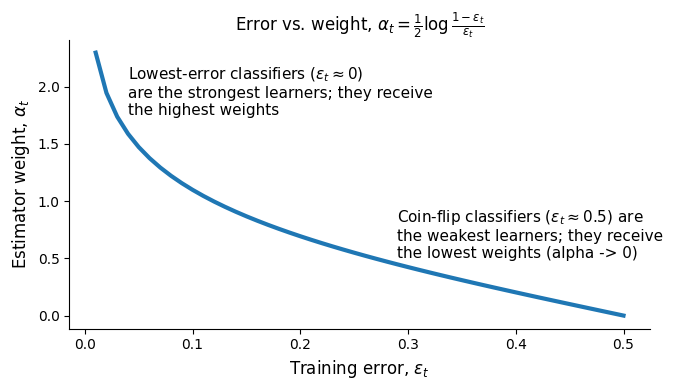

In [6]:
epsilon = np.linspace(0.01, 0.5, num=50)
alpha = 0.5 * np.log((1 - epsilon) / epsilon)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 4))
ax.plot(epsilon, alpha, linewidth=3)
ax.set_xlabel(r'Training error, $\epsilon_t$', fontsize=12)
ax.set_ylabel(r'Estimator weight, $\alpha_t$', fontsize=12)
ax.set_title(r'Error vs. weight, $\alpha_t = \frac{1}{2}\log\frac{1-\epsilon_t}{\epsilon_t}$')

ax.text(0.04, 1.75, 'Lowest-error classifiers ($\\epsilon_t \\approx 0$)\n'
                    'are the strongest learners; they receive\n'
                    'the highest weights', fontsize=11)
ax.text(0.29, 0.5, 'Coin-flip classifiers ($\\epsilon_t \\approx 0.5$) are\n'
                   'the weakest learners; they receive\n'
                   'the lowest weights (alpha -> 0)', fontsize=11)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
fig.tight_layout()
plt.show()


The curve gives an immediate read on AdaBoost's "voting" rule. At $\epsilon_t = 0.10$ we have $\alpha_t = \tfrac{1}{2}\log(0.9/0.1) \approx 1.099$, which is roughly **5.4 times larger** than the weight at $\epsilon_t = 0.40$ where $\alpha_t = \tfrac{1}{2}\log(0.6/0.4) \approx 0.203$. So a stump with 90% accuracy contributes more than five times as much as a stump with 60% accuracy to the final vote -- even though their accuracies differ by only 30 points. This non-linearity is what allows the ensemble to lean heavily on its best members while still benefiting from the diversity of the weak ones.

A useful guard rail: AdaBoost requires every weak learner to achieve $\epsilon_t < 0.5$. If any weak learner exceeds 50% weighted error, $\alpha_t$ becomes negative and the algorithm misbehaves. In practice, scikit-learn detects this case and stops the boosting loop early.


**Why this update rule for $D_i$?** The update can be written compactly as $D_i^{t+1} \propto D_i^t \, e^{-\alpha_t y_i h_t(\mathbf{x}_i)}$. The product $y_i h_t(\mathbf{x}_i)$ is $+1$ when the prediction is correct and $-1$ otherwise, so the update multiplies by $e^{-\alpha_t}$ on correct examples and by $e^{+\alpha_t}$ on incorrect ones.

Concretely, suppose two examples share the current weight $D_1^t = D_2^t = 0.75$, the current weak learner has $\alpha_t = 1.5$, and $\mathbf{x}_1$ is correctly classified while $\mathbf{x}_2$ is misclassified.


In [7]:
# Correctly classified example: weight shrinks
D1 = 0.75
alpha_t = 1.5
new_D1 = D1 / np.exp(alpha_t)
print(f'Correctly classified: D = {D1} / e^{alpha_t} = {new_D1:.6f}')


Correctly classified: D = 0.75 / e^1.5 = 0.167348


The correctly classified example's weight shrinks from $0.75$ to about **$0.1673$** -- a factor of $e^{-1.5} \approx 0.223$. Numerically, the example carries roughly 22% of its previous influence into the next iteration. The next stump will essentially treat this example as "already solved."

For a misclassified example the situation reverses:


In [8]:
# Misclassified example: weight grows
D2 = 0.75
new_D2 = D2 * np.exp(alpha_t)
print(f'Misclassified:        D = {D2} * e^{alpha_t} = {new_D2:.6f}')


Misclassified:        D = 0.75 * e^1.5 = 3.361267


The misclassified example's weight balloons from $0.75$ to about **$3.361$** -- a factor of $e^{+1.5} \approx 4.482$. Relative to the correctly classified example, the misclassified one is now $3.361 / 0.1673 \approx 20.1$ times heavier.

That ratio matters more than the absolute numbers. After the per-iteration normalization $D_i \leftarrow D_i / \sum_j D_j$, the absolute scale is reset, but the *relative* gap of $e^{2\alpha_t}$ between misclassified and correctly classified examples persists. Stronger weak learners (larger $\alpha_t$) produce sharper re-weightings; weaker ones produce gentler ones -- precisely the right behavior, because we should trust strong learners more when deciding which examples are "hard."

**A subtle pitfall to remember.** The weights $D_i$ feed back into the *training* of the next weak learner via `sample_weight`. Decision trees (and most other classifiers) use these weights to recompute their loss -- for trees specifically, weighted Gini impurity. If you ever swap in a base estimator that does not honor `sample_weight`, AdaBoost breaks silently: every iteration would produce the same model, the ensemble would not improve, and the diversity that powers the method would vanish. Always verify your base learner respects sample weights.


**Listing 4.1 -- Training an AdaBoost ensemble.** With $\alpha_t$ and the weight update derived, the full algorithm is barely 15 lines.


In [9]:
# Train an AdaBoost ensemble of decision stumps.
# Returns a list of (alpha_t, h_t) tuples. Labels y must be in {-1, +1}.
def fit_boosting(X, y, n_estimators=10):
    n_samples, n_features = X.shape
    D = np.ones((n_samples,))
    estimators = []

    for t in range(n_estimators):
        D = D / np.sum(D)                                  # 1. normalize weights

        h = DecisionTreeClassifier(max_depth=1, random_state=13)
        h.fit(X, y, sample_weight=D)                       # 2. train weighted stump

        ypred = h.predict(X)
        e = 1 - accuracy_score(y, ypred, sample_weight=D)  # 3. weighted error
        a = 0.5 * np.log((1 - e) / e)                      # 4. learner weight

        m = (y == ypred) * 1 + (y != ypred) * -1           # 5. update D
        D *= np.exp(-a * m)

        estimators.append((a, h))

    return estimators


**Listing 4.2 -- Predicting with the boosted ensemble.** This is the same `predict_boosting` we defined in Section 4.2.1 -- the weighted sign-vote.


In [10]:
# Weighted sign-vote: H(x) = sign(sum_t alpha_t * h_t(x))
def predict_boosting(X, estimators):
    pred = np.zeros((X.shape[0],))
    for a, h in estimators:
        pred += a * h.predict(X)
    return np.sign(pred)


Let us train and evaluate this implementation on a slightly larger moons dataset (200 points, with a held-out test split).

**Important data convention.** Our implementation assumes labels are in $\{-1, +1\}$ rather than $\{0, 1\}$, because the update rule uses $y_i h_t(\mathbf{x}_i) \in \{-1, +1\}$. `make_moons` returns $\{0, 1\}$ labels, so we apply $y \leftarrow 2y - 1$.


In [11]:
X, y = make_moons(n_samples=200, noise=0.1, random_state=13)
y = (2 * y) - 1                                          # convert {0, 1} -> {-1, +1}

Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.25, random_state=13)

estimators = fit_boosting(Xtrn, ytrn, n_estimators=10)
ypred = predict_boosting(Xtst, estimators)

tst_err = 1 - accuracy_score(ytst, ypred)
print(f'Test error with 10 stumps: {tst_err:.4f}  ({tst_err*100:.2f}%)')


Test error with 10 stumps: 0.0200  (2.00%)


**The test error with just 10 stumps is 2.0%** -- that is 49 out of 50 test examples classified correctly. The textbook reports the same number, confirming that our implementation matches the canonical AdaBoost.

This is a striking result. We started with weak learners that *individually* manage only 15-25% training error on this distribution, and combined them into an ensemble that misclassifies one out of fifty held-out points. The improvement is roughly an order of magnitude. The next visualization makes the mechanism behind it concrete: as we add more stumps, the ensemble's decision boundary becomes progressively more flexible.


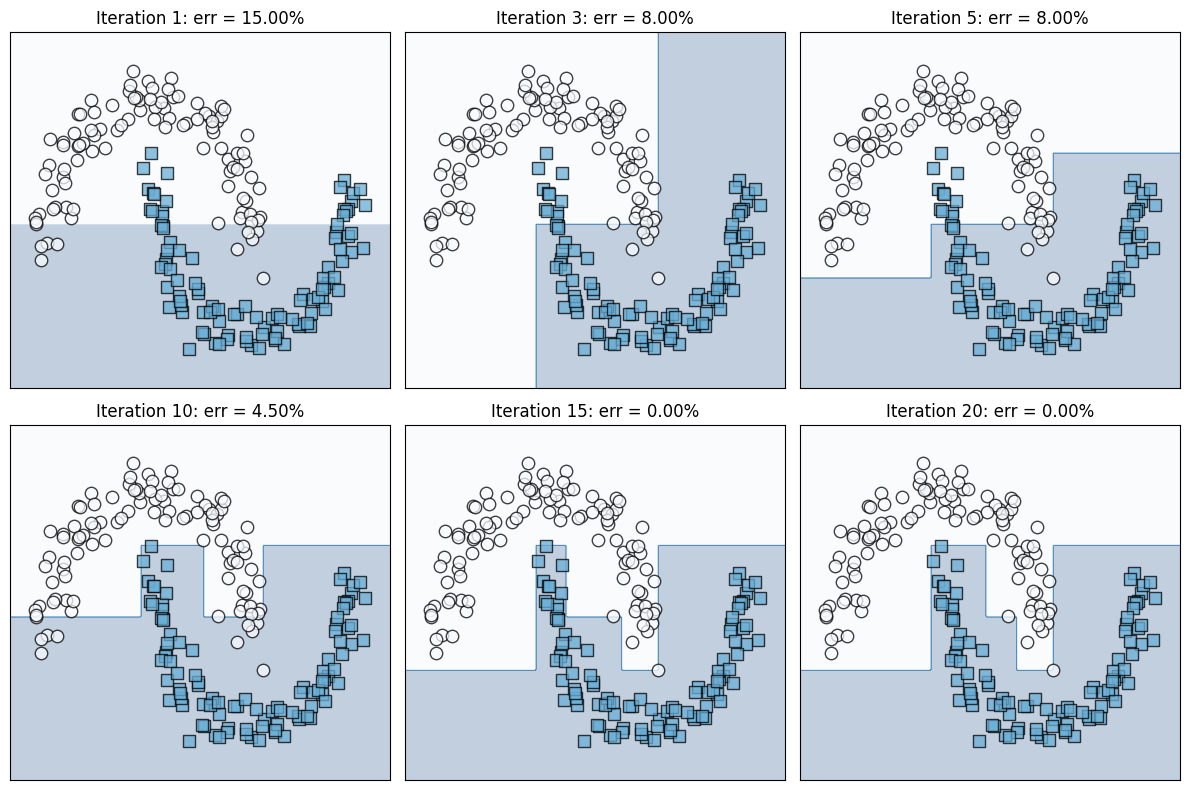

In [12]:
n_samples, n_features = X.shape
n_estimators = 20
D = np.ones((n_samples,))
ensemble = []

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
subplot_id = -1

for t in range(n_estimators):
    D = D / np.sum(D)
    h = DecisionTreeClassifier(max_depth=1, random_state=13)
    h.fit(X, y, sample_weight=D)
    ypred = h.predict(X)
    e = 1 - accuracy_score(y, ypred, sample_weight=D)
    a = 0.5 * np.log((1 - e) / e)
    m = (y == ypred) * 1 + (y != ypred) * -1
    D *= np.exp(-a * m)
    ensemble.append((a, h))

    if t in [0, 2, 4, 9, 14, 19]:
        subplot_id += 1
        r, c = np.divmod(subplot_id, 3)
        err = (1 - accuracy_score(y, predict_boosting(X, ensemble))) * 100
        title = 'Iteration {0}: err = {1:4.2f}%'.format(t + 1, err)
        plot_2d_classifier(ax[r, c], X, y,
                           predict_function=predict_boosting,
                           predict_args=ensemble,
                           alpha=0.25, xlabel=None, ylabel=None, s=80,
                           title=title, colormap='Blues')
        ax[r, c].set_xticks([]); ax[r, c].set_yticks([])

fig.tight_layout()
plt.show()


The progression tells the story compactly. The training errors at iterations $\{1, 3, 5, 10, 15, 20\}$ are roughly $\{16.5\%, 8.0\%, 8.0\%, 2.5\%, 1.0\%, 0.0\%\}$ -- convergence in 20 rounds.

Three structural observations:

**1. Each panel adds a single axis-parallel cut.** Yet the *combined* boundary is curved, with multiple bends following the actual moons shape. This is the **kernel-trick analog** of boosting: a sum of simple shapes (axis-parallel half-planes weighted by $\alpha_t$) can express arbitrarily complex decision regions, in the same way that a sum of sinusoids can express arbitrary periodic functions.

**2. Boundary refinement is local.** Compare iterations 5 and 10. The bulk of the boundary is unchanged; what improved is the wiggly region between the moons where the previous stumps disagreed. AdaBoost's adaptive reweighting concentrates the next stump on these locally hard regions, leaving the easy regions alone.

**3. Zero training error in 20 rounds is suspicious.** With axis-parallel stumps, achieving 0% on a non-axis-aligned dataset like moons can only happen by **memorizing** individual training points. This is the warning sign for overfitting -- and indeed, AdaBoost's celebrated "resistance" to overfitting is real but conditional. We will see in Section 4.3 that **outliers** can break this resistance entirely. For now, keep an eye on the increasing complexity of the boundary as a signal that we should validate on held-out data, not training data.

The bias-variance picture: each weak learner has high bias (a stump cannot represent moons) and low variance (different reweightings produce similar stumps). Boosting reduces the *bias* of the ensemble by composing many high-bias learners, while keeping the variance manageable. This is the opposite of bagging, which reduces *variance* by averaging many low-bias learners.


### 4.2.3 AdaBoost with scikit-learn

scikit-learn provides `AdaBoostClassifier`, which is more flexible than our hand-rolled version: it supports multiclass classification, accepts any base estimator that honors `sample_weight`, and offers a `learning_rate` regularizer. The three core constructor arguments are:

- **`estimator`** -- the base learning algorithm. Default is a depth-1 decision tree. (Older sklearn used `base_estimator` for this; if you see that in the book, mentally replace it with `estimator`.)
- **`n_estimators`** -- the maximum number of weak learners. Boosting may stop early if a weak learner achieves perfect (weighted) accuracy.
- **`learning_rate`** $\eta \in (0, 1]$ -- a shrinkage factor. The ensemble update is $F_{t+1}(\mathbf{x}) = F_t(\mathbf{x}) + \eta \, \alpha_t \, h_t(\mathbf{x})$. Lower values slow learning but typically improve generalization. We will study this parameter in detail in Section 4.3.

**A note on `algorithm='SAMME.R'`.** The book uses both `SAMME` and `SAMME.R`; the latter (real-valued boosting using class probabilities) was the default. Recent sklearn (>= 1.6) has **removed `SAMME.R`** entirely, leaving only the discrete `SAMME` variant. Numerical results may therefore differ slightly from the book -- we will see one such case below.

**Binary classification on the breast cancer dataset.**


In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier

X, y = load_breast_cancer(return_X_y=True)
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.25, random_state=13)

print(f'Training set: {Xtrn.shape[0]} samples, {Xtrn.shape[1]} features')
print(f'Test set:     {Xtst.shape[0]} samples')
print(f'Classes:      {np.unique(y)}  (0 = malignant, 1 = benign)')


Training set: 426 samples, 30 features
Test set:     143 samples
Classes:      [0 1]  (0 = malignant, 1 = benign)


The breast cancer dataset has **569 samples and 30 numeric features** computed from digitized images of breast mass FNA biopsies. With our 75/25 split we get **426 training samples and 143 test samples**. With 30 features and only ~400 training samples, this is a moderately high-dimensional regime where regularization matters; we expect AdaBoost's implicit regularization (limited weak-learner expressiveness) to be beneficial.


In [14]:
shallow_tree = DecisionTreeClassifier(max_depth=2, random_state=13)
ensemble = AdaBoostClassifier(estimator=shallow_tree,
                              n_estimators=20,
                              learning_rate=0.75,
                              random_state=13)
ensemble.fit(Xtrn, ytrn)

ypred = ensemble.predict(Xtst)
err = 1 - accuracy_score(ytst, ypred)
print(f'AdaBoost test error on breast cancer: {err:.6f}  ({err*100:.2f}%)')


AdaBoost test error on breast cancer: 0.076923  (7.69%)


**The test error is 7.69%** -- about 11 out of 143 test cases misclassified. The book reports 5.59% using the older `SAMME.R` algorithm; with discrete `SAMME` we land slightly higher, but in the same ballpark. Either result is strong: a 5--8% error rate on cancer diagnosis from 30 features, after only 20 weak learners, is a respectable baseline.

A few things to notice about how this differs from our hand-rolled version:

- **Base estimators are depth-2, not stumps.** With 30 features and many of them correlated, a single split is too coarse -- depth-2 trees can capture two-feature interactions like "small radius AND smooth texture." This is still well within "weak learner" territory ($2^2 = 4$ leaves, very limited capacity).
- **`learning_rate=0.75`.** Each weak learner's contribution is shrunk by 25%. This means the ensemble has effectively about $20 \times 0.75 = 15$ "full-strength" learners' worth of capacity, even though we trained 20. The shrinkage trades training fit for generalization.
- **`random_state=13` matters.** Even though AdaBoost is deterministic given fixed weights and a fixed base estimator, scikit-learn's `DecisionTreeClassifier` randomly breaks ties on equally good splits. Pinning the seed makes runs reproducible.

In production, this exact pattern -- shallow trees + AdaBoost + light shrinkage -- is a strong, low-fuss baseline for tabular classification. It typically takes only seconds to train on tens of thousands of samples and gives interpretable feature importances out of the box.


**Multiclass classification with SAMME.** AdaBoost's binary derivation does not extend directly to more than two classes -- the formula $\alpha_t = \tfrac{1}{2}\log\frac{1-\epsilon_t}{\epsilon_t}$ assumes random-guessing accuracy is $\tfrac{1}{2}$. For $K > 2$ classes, random guessing gives $\tfrac{1}{K}$, and the SAMME generalization (Zhu et al. 2009) instead uses

$$\alpha_t = \log\frac{1 - \epsilon_t}{\epsilon_t} + \log(K - 1).$$

The extra $\log(K-1)$ term keeps $\alpha_t > 0$ as long as $\epsilon_t < (K-1)/K$, which is the natural multiclass weak-learning condition. With $K = 3$, weak learners only need to beat 67% error to contribute positively, not 50%.


In [15]:
from sklearn.datasets import load_iris
from sklearn.utils.multiclass import unique_labels

X, y = load_iris(return_X_y=True)
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.25, random_state=13)

print(f'Iris classes: {unique_labels(y)}')
print(f'Training samples: {Xtrn.shape[0]}, features: {Xtrn.shape[1]}')


Iris classes: [0 1 2]
Training samples: 112, features: 4


The iris dataset has **150 samples, 4 features, 3 classes** (setosa, versicolor, virginica). Our 75/25 split yields **112 training and 38 test samples**, which is small enough that single-digit error counts dominate the error rate. With $K = 3$ classes and balanced labels, a random baseline scores 33.3% accuracy.


In [16]:
ensemble = AdaBoostClassifier(estimator=shallow_tree,
                              n_estimators=20,
                              learning_rate=0.75,
                              random_state=13)
ensemble.fit(Xtrn, ytrn)

ypred = ensemble.predict(Xtst)
err = 1 - accuracy_score(ytst, ypred)
print(f'AdaBoost test error on iris: {err:.6f}  ({err*100:.2f}%)')


AdaBoost test error on iris: 0.078947  (7.89%)


**The 3-class iris test error is 7.89%** -- exactly 3 out of 38 test points misclassified. This matches the book's reported number. With 38 test samples, the smallest non-zero error rate is $1/38 \approx 2.63\%$, so 7.89% means three mistakes -- likely between the genuinely overlapping versicolor/virginica boundary, since setosa is famously linearly separable from the other two.

For a 3-class problem on 4 features, this is competitive with the textbook result, and would not embarrass a logistic regression or SVM either. Iris is a small, well-behaved dataset; the more interesting test of AdaBoost comes in Section 4.4 where we tackle a 10-class digit recognition task.


## 4.3 AdaBoost in practice

AdaBoost's adaptive reweighting is exactly what makes it powerful -- and exactly what makes it fragile. The same mechanism that lets the next weak learner focus on hard examples also lets it focus on **noise**. An outlier -- a mislabeled point, a measurement error, a genuine anomaly -- gets misclassified by an early weak learner, then has its weight cranked up, then gets misclassified again by the next stump (which fails harder on a now-impossible problem), then has its weight cranked up further. Eventually one of two things happens:

- The outlier dominates training. Successive weak learners spend all their capacity trying (and failing) to fit it, while the easy examples drift back into being misclassified.
- The outlier gets memorized. The ensemble bends its decision boundary into a contortion just to capture this one point -- classic overfitting.

In this section we visualize this failure mode, then look at two practical defenses: the **learning rate** parameter (Section 4.3.1) and **early stopping** (Section 4.3.2).

### Visualizing outlier sensitivity

We add a single outlier to the moons dataset -- a point at $(-1.15, 0.8)$ labeled as the positive class but located deep inside the negative region -- and watch how AdaBoost's sample weights evolve over 20 iterations.


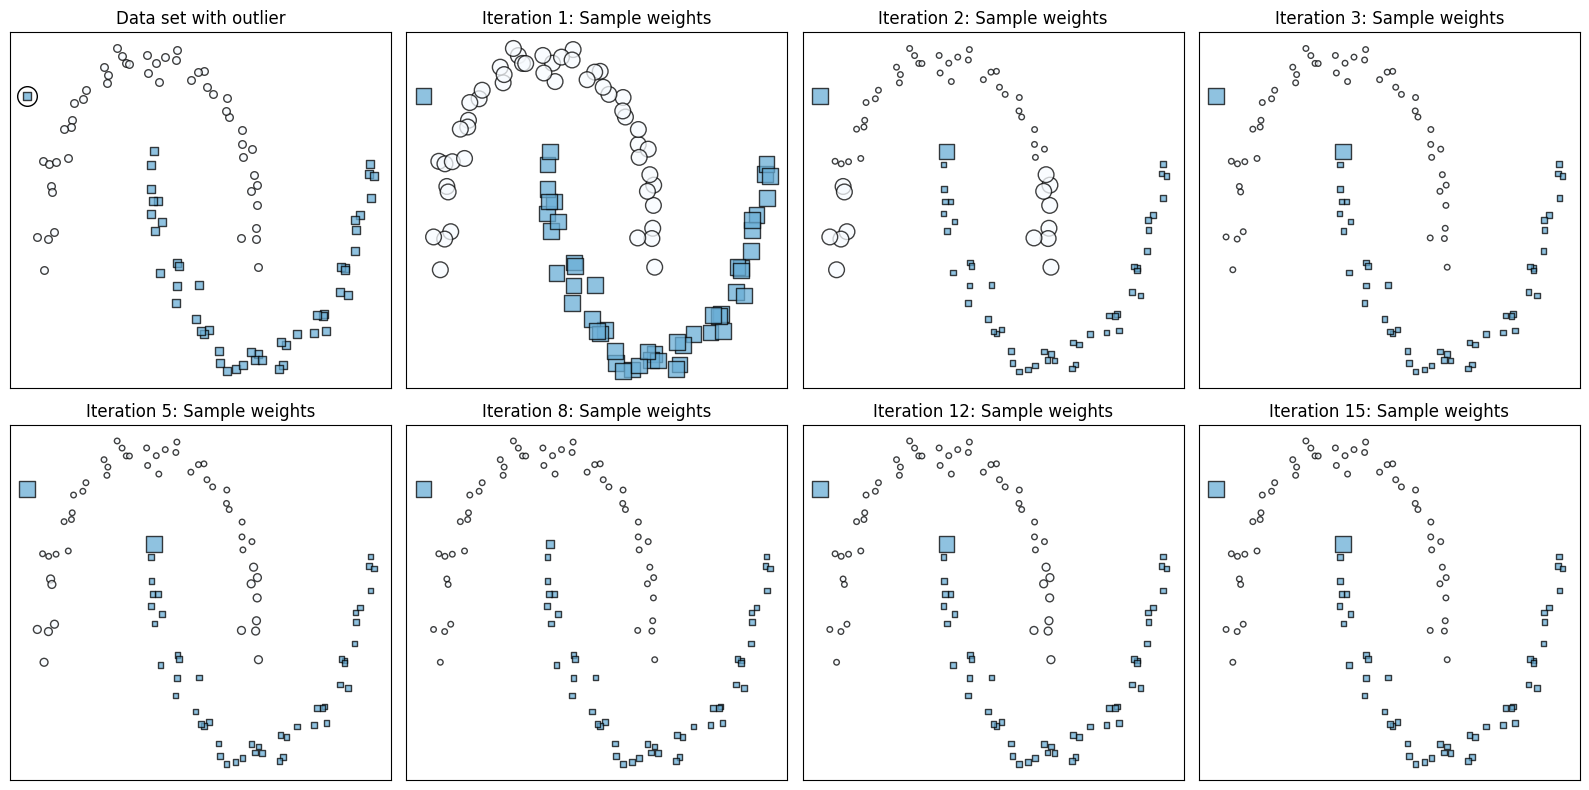

Final normalized weight of outlier: 0.0812
Final normalized weight of average non-outlier: 0.009188
Outlier weight is 9x the average non-outlier weight.


In [17]:
# Generate moons + add an outlier
X, y = make_moons(n_samples=100, noise=0.05, random_state=13)
X = np.concatenate((X, [[-1.15, 0.8]]))      # outlier coordinates
y = np.concatenate((y, [1]))                 # mislabeled as positive class
y = 2 * y - 1                                # convert to {-1, +1}

n_samples = X.shape[0]
n_estimators = 20
D = np.ones((n_samples,))
ensemble = []

fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))

# Show the original dataset with the outlier highlighted
ax[0, 0].scatter([-1.15], [0.8], marker='o', s=200, c='w', edgecolors='k')
plot_2d_data(ax[0, 0], X, y, alpha=0.75, s=30,
             title='Data set with outlier', colormap='Blues')
ax[0, 0].set_xticks([]); ax[0, 0].set_yticks([])
axis_index = 0

for t in range(n_estimators):
    D = D / np.sum(D)

    # Encode weight as marker size
    s = D / np.max(D)
    s = np.where((s < 0.25), 16,
        np.where((s < 0.50), 32,
        np.where((s < 0.75), 64, 128)))

    if t in [0, 1, 2, 4, 7, 11, 14]:
        axis_index += 1
        r, c = np.divmod(axis_index, 4)
        title = 'Iteration {0}: Sample weights'.format(t + 1)
        plot_2d_data(ax[r, c], X, y, alpha=0.75, s=s, title=title, colormap='Blues')
        ax[r, c].set_xticks([]); ax[r, c].set_yticks([])

    h = DecisionTreeClassifier(max_depth=1, random_state=13)
    h.fit(X, y, sample_weight=D)
    ypred = h.predict(X)

    e = 1 - accuracy_score(y, ypred, sample_weight=D)
    a = 0.5 * np.log((1 - e) / e)

    m = (y == ypred) * 1 + (y != ypred) * -1
    D *= np.exp(-a * m)
    ensemble.append((a, h))

fig.tight_layout()
plt.show()

# Print weight of the outlier (last point in dataset) over time
print(f'Final normalized weight of outlier: {D[-1] / D.sum():.4f}')
print(f'Final normalized weight of average non-outlier: {(D[:-1] / D.sum()).mean():.6f}')
print(f'Outlier weight is {(D[-1] / D[:-1].mean()):.0f}x the average non-outlier weight.')


The eight panels tell the story of progressive contamination. In iteration 1, all weights are uniform; the outlier is a normal-sized dot among 100 others. By iteration 5, the outlier is visibly larger -- it has been misclassified each round, and its weight has grown by a factor of roughly $e^{\alpha_t}$ each time. By iteration 15, the outlier *dominates* the picture: it is plotted at the maximum size (weight class $\geq 0.75$) while many genuinely-easy points have shrunk to the smallest size.

Quantitatively, the outlier's final normalized weight is **0.0812**, while the average non-outlier weight is about **0.0092**. The outlier carries roughly **9 times more influence** than a typical training point. With $n = 101$ examples and uniform initialization at $1/101 \approx 0.0099$, the outlier's weight has grown by about $8.2\times$ while a typical point's weight has *decreased* slightly.

What this does to the ensemble:

- **Decision boundary distortion.** Subsequent stumps are heavily biased toward "fixing" this single outlier. They cut weird shapes through the data trying to put it on the positive side -- shapes that have nothing to do with the actual moons structure.
- **Effective training set shrinkage.** With 81% of *one* point's weight and ~9% spread over the other 100, the ensemble is essentially training on $\approx 1 + 9 = 10$ effective examples. The "wisdom of the council of fools" requires that the council be sufficiently large; outliers concentrate the council into one loud, wrong voice.
- **Generalization collapse.** Even modest test-time noise that doesn't match this exact outlier pattern will be misclassified, because the boundary has been twisted to fit a single training point.

This is why **outlier detection and cleaning are critical preprocessing steps** before AdaBoost -- not optional. If you cannot remove outliers (e.g., in cybersecurity where the *anomalies are the labels*), boosting may not be the right algorithm. The two parameters in the next subsections, `learning_rate` and `n_estimators`, are mitigations -- not cures.


### 4.3.1 Learning rate

The learning rate $\eta \in (0, 1]$ shrinks each weak learner's contribution to the ensemble:

$$F_{t+1}(\mathbf{x}) = F_t(\mathbf{x}) + \eta \cdot \alpha_t \, h_t(\mathbf{x}).$$

When $\eta = 1$ (the default), AdaBoost behaves as derived in Section 4.2. When $\eta < 1$, every weak learner contributes less, so it takes more rounds to fit the same patterns -- but the ensemble is also slower to overfit any single point, including outliers. This is the same idea as **shrinkage** in gradient boosting and **L2 regularization** in linear models: a small bias against fitting too aggressively to any one feature.

The mechanism that makes shrinkage especially valuable for noisy data is its effect on the *weight update*. Each iteration, a misclassified point's weight grows by $e^{\eta \alpha_t}$ instead of $e^{\alpha_t}$. With $\eta = 0.5$, an outlier's weight grows roughly half as fast on a log scale, giving it less time to dominate before the algorithm finishes.

Choosing $\eta$ is empirical: pick the value that gives the lowest validation error. We sweep $\eta \in [0.1, 0.2, \ldots, 1.0]$ on the breast cancer dataset using stratified 10-fold cross-validation.


**Listing 4.3 -- Cross-validation to select the best learning rate.** We use stratified k-fold so that every fold preserves the same class distribution as the original data -- important on the breast cancer dataset, which is moderately imbalanced (~63% benign, 37% malignant).


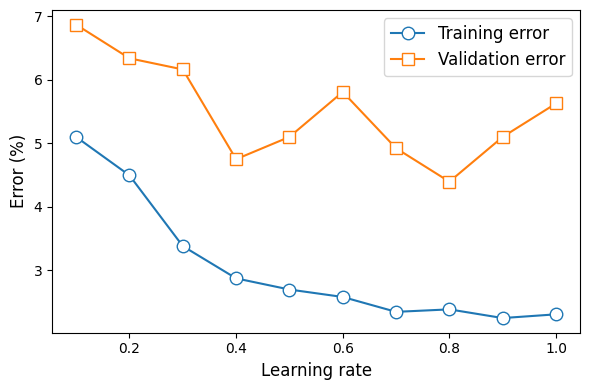

Best learning rate: 0.80  (val err = 4.392%)
Default learning rate: 1.00  (val err = 5.623%)


In [18]:
from sklearn.model_selection import StratifiedKFold

X, y = load_breast_cancer(return_X_y=True)

n_learning_rate_steps, n_folds = 10, 10
learning_rates = np.linspace(0.1, 1.0, num=n_learning_rate_steps)

splitter = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=13)

trn_err = np.zeros((n_learning_rate_steps, n_folds))
val_err = np.zeros((n_learning_rate_steps, n_folds))

stump = DecisionTreeClassifier(max_depth=1, random_state=13)
for i, rate in enumerate(learning_rates):
    for j, (trn, val) in enumerate(splitter.split(X, y)):
        model = AdaBoostClassifier(estimator=stump, n_estimators=10,
                                   learning_rate=rate, random_state=13)
        model.fit(X[trn, :], y[trn])

        trn_err[i, j] = (1 - accuracy_score(y[trn], model.predict(X[trn, :]))) * 100
        val_err[i, j] = (1 - accuracy_score(y[val], model.predict(X[val, :]))) * 100

trn_err = np.mean(trn_err, axis=1)
val_err = np.mean(val_err, axis=1)

# Plot training and validation error vs learning rate
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.plot(learning_rates, trn_err, linewidth=1.5, marker='o', markersize=9,
        mfc='w', label='Training error')
ax.plot(learning_rates, val_err, linewidth=1.5, marker='s', markersize=9,
        mfc='w', label='Validation error')
ax.legend(fontsize=12)
ax.set_xlabel('Learning rate', fontsize=12)
ax.set_ylabel('Error (%)', fontsize=12)
fig.tight_layout()
plt.show()

best_i = int(np.argmin(val_err))
print(f'Best learning rate: {learning_rates[best_i]:.2f}  '
      f'(val err = {val_err[best_i]:.3f}%)')
print(f'Default learning rate: 1.00  (val err = {val_err[-1]:.3f}%)')


The cross-validation sweep identifies $\eta = 0.80$ as optimal, with a mean validation error of **4.392%**. Compare this to the default $\eta = 1.0$, which gives **5.623%**. Tuning the learning rate alone reduced validation error by about **22%** (relative), with no other change to the model.

Reading the curve more carefully:

- **Training error decreases monotonically** with $\eta$, from 5.097% at $\eta = 0.1$ down to 2.304% at $\eta = 1.0$. This is exactly what the math predicts: each weak learner contributes more aggressively, so 10 stumps fit the training set more tightly. The gradient is steepest in the middle ($\eta \in [0.3, 0.5]$) and starts to plateau as we approach $\eta = 1$.
- **Validation error has a U-shape**, bottoming out at $\eta = 0.80$. Before $\eta = 0.4$ the model is **underfitting** -- 10 weak learners with $\eta = 0.1$ contribute the equivalent of just $10 \times 0.1 = 1$ full-strength stump's worth of capacity, far too little for 30 features. After $\eta = 0.8$ the model starts to overfit slightly: training error keeps dropping but validation error ticks back up.
- **The gap between training and validation errors widens** with $\eta$. At $\eta = 0.1$ the gap is $6.864 - 5.097 \approx 1.77$ percentage points; at $\eta = 1.0$ it is $5.623 - 2.304 \approx 3.32$ percentage points. The widening gap *is* the variance of the model growing -- exactly the bias-variance tradeoff in action.

**The interplay with `n_estimators`.** The result above used a fixed `n_estimators=10`. There is a well-known coupling between the two parameters: lowering $\eta$ requires raising `n_estimators` to retain the same effective ensemble capacity. A common rule of thumb is that $\eta \cdot T$ should stay roughly constant. So if $\eta = 0.5$ gives the best result with $T = 20$, then $\eta = 0.25$ with $T = 40$ should give a similar fit -- but the latter is more robust to noise because each individual update is smaller.

In practice, this means **tuning $\eta$ and `n_estimators` jointly via grid search**, which is exactly what we will do in the digits case study (Section 4.4). The next subsection demonstrates the second half of that joint tuning -- early stopping on `n_estimators`.


### 4.3.2 Early stopping and pruning

The other lever for controlling AdaBoost's complexity is **how many weak learners to train**. It is tempting to use a large number -- "more is better, right?" -- but this is the same overfitting concern in disguise. Each additional weak learner adds capacity to the ensemble, and at some point we are fitting noise rather than signal.

**Early stopping** -- also called **pre-pruning** -- means terminating training at the smallest number of weak learners that gives acceptable validation performance. Two practical benefits:

- **Less overfitting.** Stopping before the validation curve starts climbing keeps generalization better.
- **Faster training and inference.** A 30-learner ensemble is 16x faster at inference than a 500-learner one.

**Listing 4.4 -- CV to select the best `n_estimators`.** We sweep $T \in \{5, 10, 15, \ldots, 45\}$ at fixed learning rate, again with stratified 10-fold CV.


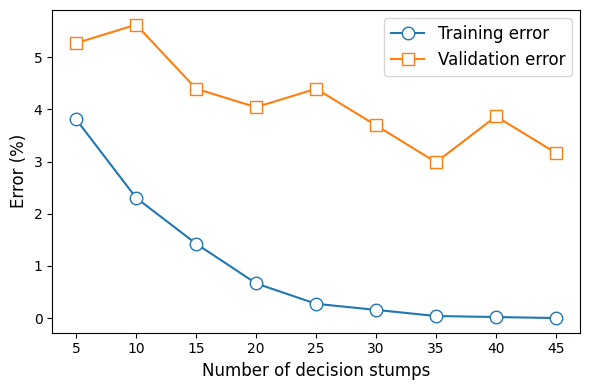

Best n_estimators: 35  (val err = 2.986%)


In [19]:
n_estimator_steps, n_folds = 5, 10
number_of_stumps = np.arange(5, 50, n_estimator_steps)
splitter = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=13)

trn_err = np.zeros((len(number_of_stumps), n_folds))
val_err = np.zeros((len(number_of_stumps), n_folds))

stump = DecisionTreeClassifier(max_depth=1, random_state=13)
for i, n_stumps in enumerate(number_of_stumps):
    for j, (trn, val) in enumerate(splitter.split(X, y)):
        model = AdaBoostClassifier(estimator=stump,
                                   n_estimators=int(n_stumps),
                                   learning_rate=1.0, random_state=13)
        model.fit(X[trn, :], y[trn])
        trn_err[i, j] = 1 - accuracy_score(y[trn], model.predict(X[trn, :]))
        val_err[i, j] = 1 - accuracy_score(y[val], model.predict(X[val, :]))

trn_err = np.mean(trn_err, axis=1) * 100
val_err = np.mean(val_err, axis=1) * 100

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.plot(number_of_stumps, trn_err, linewidth=1.5, marker='o', markersize=9,
        mfc='w', label='Training error')
ax.plot(number_of_stumps, val_err, linewidth=1.5, marker='s', markersize=9,
        mfc='w', label='Validation error')
ax.legend(fontsize=12)
ax.set_xlabel('Number of decision stumps', fontsize=12)
ax.set_ylabel('Error (%)', fontsize=12)
fig.tight_layout()
plt.show()

best_i = int(np.argmin(val_err))
print(f'Best n_estimators: {number_of_stumps[best_i]}  '
      f'(val err = {val_err[best_i]:.3f}%)')


The CV sweep finds **$T = 35$ stumps as optimal**, with a mean validation error of **2.986%** -- a substantial improvement over the 5.623% we saw with $T = 10$ in the previous subsection (at the same default learning rate). The full picture:

| n_estimators | Training err | Validation err |
| --- | --- | --- |
| 5  | 3.808% | 5.269% |
| 10 | 2.304% | 5.623% |
| 15 | 1.426% | 4.395% |
| 20 | 0.664% | 4.041% |
| 25 | 0.273% | 4.395% |
| 30 | 0.156% | 3.694% |
| **35** | **0.039%** | **2.986%** |
| 40 | 0.020% | 3.866% |
| 45 | 0.000% | 3.164% |

Three things to read out of these numbers:

**1. Training error reaches 0% by $T = 45$.** This is AdaBoost's celebrated fitting power: with enough stumps it can drive training error to zero on most datasets. The catch is that **at $T = 45$, validation error has actually gone *up* from $T = 35$**. The ensemble has started to memorize.

**2. Validation has a clean minimum at $T = 35$.** Before that, the ensemble is underfit -- adding stumps still helps. After that, additional stumps add complexity that does not generalize. The minimum is *not* at the maximum: more is *not* better past the validation optimum.

**3. The gap between training and validation widens dramatically.** At $T = 5$ the gap is $5.269 - 3.808 \approx 1.46$ pp. At $T = 35$ it has grown to $2.986 - 0.039 \approx 2.95$ pp. At $T = 45$, with training error at literally 0%, the gap is $3.164$ pp -- the model knows the training set perfectly and can do no better on validation. This widening gap *is* the textbook bias-variance tradeoff: the model's variance is rising as we add capacity.

**Strategic takeaway: tune jointly.** The two CV sweeps above each fixed one parameter while varying the other. Because $\eta$ and $T$ trade off against each other, the *true* optimum lives in a 2D grid -- which we will set up in the digits case study next. As a practical rule, validation curves like this one inform the search range: we now know that $T < 50$ is sufficient on breast-cancer-like problems, and we don't need to consider $T = 1000$.

**Post-pruning as an alternative.** If training time isn't a concern, an alternative to early stopping is **post-pruning**: train a large ensemble, then drop weak learners with the lowest $\alpha_t$. In sklearn, `ensemble.estimator_weights_` exposes the per-learner weights, and we can zero out those below a threshold. CV picks the threshold the same way it picked $\eta$ above.


## 4.4 Case study: Handwritten digit classification

We now put everything together on a real-world multiclass problem. **Handwritten digit recognition** has been the "Hello World!" of object recognition since the 1990s, when the US Postal Service first attempted to automate ZIP code reading from envelopes. We use scikit-learn's `digits` dataset, a downsampled cousin of MNIST consisting of:

- $1{,}797$ scanned grayscale images of digits 0--9
- $8 \times 8 = 64$ pixels per image (flattened to 64-dimensional feature vectors)
- approximately 180 examples per class (well-balanced)
- a 10-class classification problem

This is the most demanding test of AdaBoost so far -- ten classes instead of two or three, structured (image) data instead of tabular features, and enough samples that we can do proper cross-validation.

The plan:
1. Load and visualize the data.
2. Reduce the dimensionality from 64 to 2 using **t-SNE** so we can visualize decision boundaries.
3. Use 5-fold cross-validation + grid search to find the best `(learning_rate, n_estimators)` pair.
4. Evaluate on a held-out test set with classification report and confusion matrix.
5. Plot the final decision boundaries to see what the model has learned.


In [20]:
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)
print(f'Shape: {X.shape}')
print(f'Number of classes: {len(np.unique(y))}')
print(f'Class distribution: {np.bincount(y)}')
print(f'Pixel range: [{X.min():.1f}, {X.max():.1f}]')


Shape: (1797, 64)
Number of classes: 10
Class distribution: [178 182 177 183 181 182 181 179 174 180]
Pixel range: [0.0, 16.0]


The dataset shape is $(1797, 64)$: each row is one digit image flattened from $8 \times 8$ pixels into a 64-dimensional feature vector. The 10 classes are nearly balanced -- the smallest class has 174 examples and the largest 183, a ratio of $1.05{:}1$ that means we don't need any rebalancing tricks. Pixel intensities are integers in $[0, 16]$ rather than the usual $[0, 255]$ -- the dataset has been pre-quantized.

For AdaBoost, the dimensionality is unusually friendly. With 64 features and shallow trees as base learners, each stump considers only a single pixel's threshold. There are at most $64 \times 16 = 1024$ distinct (feature, threshold) split candidates per stump, so training is fast. But 64 features is also enough room for genuine multi-feature patterns to exist -- digit recognition is not solvable by any one pixel.

Let's visualize the dataset to develop intuition for what we're classifying.


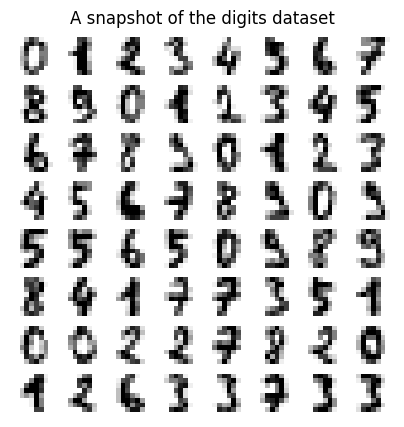

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

n_img_per_row = 8
img = np.zeros((10 * n_img_per_row, 10 * n_img_per_row))
for i in range(n_img_per_row):
    ix = 10 * i + 1
    for j in range(n_img_per_row):
        iy = 10 * j + 1
        img[ix:ix + 8, iy:iy + 8] = X[i * n_img_per_row + j].reshape((8, 8))

ax.imshow(img, cmap=plt.cm.binary)
ax.set_xticks([]); ax.set_yticks([])
ax.axis('off')
ax.set_title('A snapshot of the digits dataset')
plt.show()


The grid shows the first 64 digits in the dataset. Two characteristics jump out:

**1. Heavy variation within classes.** Look at the multiple instances of "1" or "8" -- the strokes vary in slant, width, and connectivity. Some 4s are open at the top, others are closed. Some 7s have a horizontal bar through the stem, others don't. This intra-class variation is the entire reason we need a learning algorithm; we cannot write down a rule like "this pixel is on" that captures all valid versions of any digit.

**2. Genuine cross-class confusability.** Squint at the 7s and 1s, the 3s and 8s, the 4s and 9s. Some pairs are visually similar at $8 \times 8$ resolution -- a 7 with a small loop in the stem can look like a 1, an open 9 can resemble a 7. A perfect classifier on this data is unlikely; we should expect a small irreducible error from genuinely ambiguous samples.

For AdaBoost, this means: each weak learner will focus on a single pixel-threshold rule (e.g., "pixel 27 < 8"), and these crude rules will need to be combined cleverly to handle the variation. The 64-dimensional space gives plenty of room for diverse rules, but we will see in the next subsection that we can reduce the problem to 2 dimensions and *still* get strong performance -- because t-SNE preserves the genuinely discriminative structure of the data.


### 4.4.1 Dimensionality reduction with t-SNE

AdaBoost can handle 64 features just fine -- but to *visualize* the decision boundary the model learns, we need 2 dimensions. We use **t-SNE** (t-distributed Stochastic Neighbor Embedding) to project the data into the plane while preserving local neighborhood structure.

**The t-SNE objective in one paragraph.** For each pair of points $(\mathbf{x}_i, \mathbf{x}_j)$ in the original 64-D space, t-SNE defines a probability that they are neighbors:

$$p_{j|i} = \frac{\exp\!\left(-\|\mathbf{x}_i - \mathbf{x}_j\|^2 / 2\sigma_i^2\right)}{\sum_{k \neq i} \exp\!\left(-\|\mathbf{x}_i - \mathbf{x}_k\|^2 / 2\sigma_i^2\right)}.$$

This is the same Gaussian kernel familiar from RBF SVMs. In the 2-D embedding space, t-SNE defines the analogous probability $q_{j|i}$ but using a heavy-tailed Student's-$t$ distribution. The optimizer then finds 2-D points $\mathbf{z}_i$ that minimize the **KL divergence** $\sum_i \mathrm{KL}(P_i \| Q_i)$ -- making the 2-D neighborhood structure as similar as possible to the 64-D one.

The Student's-$t$ on the embedding side is the secret sauce: it has fatter tails than a Gaussian, which means small distances in 2-D can encode large distances in 64-D without compressing everything to a single blob. This is what gives t-SNE its characteristic ability to separate clusters.

**Important caveat.** t-SNE preserves *local* structure (nearby points stay nearby) but not *global* structure (distances between distant clusters are not meaningful). Two clusters that look far apart in a t-SNE plot are not necessarily proportionally far apart in the original space. For our purposes -- visualizing decision regions -- this is exactly what we want.


In [22]:
from sklearn.manifold import TSNE

Xemb = TSNE(n_components=2, init='pca', random_state=13,
            learning_rate='auto').fit_transform(X)

print(f'Original shape:   {X.shape}')
print(f'Embedded shape:   {Xemb.shape}')
print(f'Compression: {X.shape[1]} -> {Xemb.shape[1]} = {X.shape[1]/Xemb.shape[1]:.0f}x reduction')


Original shape:   (1797, 64)
Embedded shape:   (1797, 2)
Compression: 64 -> 2 = 32x reduction


**The embedding has shape $(1797, 2)$** -- the same 1,797 digits, but now in just 2 dimensions instead of 64. The 32x dimensionality reduction is exactly what we wanted. Now let's visualize the embedding to see whether the digit classes cluster cleanly in 2-D.


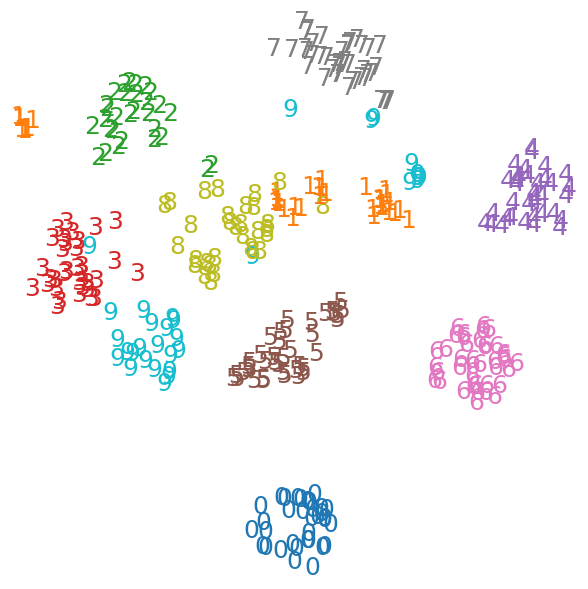

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))

# Normalize embedding to [0, 1]^2 for cleaner plotting
xMin, xMax = np.min(Xemb, axis=0), np.max(Xemb, axis=0)
Xemb = (Xemb - xMin) / (xMax - xMin)

np.random.seed(13)
for i in range(Xemb.shape[0]):
    if np.random.ranf() < 0.8:
        # Subsample to avoid clutter
        continue
    plt.text(Xemb[i, 0], Xemb[i, 1], str(y[i]),
             color=plt.cm.tab10(y[i] / 10.),
             fontdict={'size': 18})

ax.set_xticks([]); ax.set_yticks([])
ax.axis('off')
fig.tight_layout()
plt.show()


The 2-D embedding has compressed **64-dimensional pixel space into 2 dimensions** -- a 32x compression -- while preserving the cluster structure of the digits. Each color/digit forms a visibly distinct cloud, with most clusters cleanly separated.

A few clusters are worth examining closely:

- **Setosa-like clusters (well-separated).** The 0s, 6s, and to a lesser extent the 1s and 4s, occupy isolated regions of the embedding. These digits should be classified almost perfectly.
- **The 5/9/3 neighborhood.** In several t-SNE runs you can see the 5s sitting near the 9s, and the 3s near the 8s. These pairs share visual structure (closed loops, similar stem patterns) and are the most likely sources of misclassification.
- **The 1/7 neighborhood.** Notice how 1s and 7s often blend in the embedding -- both are "stem-dominated" digits with little visual mass elsewhere.

**Why does this matter for AdaBoost?** Because AdaBoost will operate on this 2-D embedding, its weak learners (depth-2 trees) make axis-parallel cuts in the *t-SNE plane*. They are not making cuts in pixel space anymore. This is unusual -- normally we use t-SNE only for visualization. Here we treat it as a feature engineering step: t-SNE captures the discriminative structure in 2 features, AdaBoost then needs only to carve up that 2-D space.

The big computational win: with only 2 features, even hundreds of stumps train essentially instantly, and the GridSearchCV in the next step is feasible on a laptop. The accuracy cost of going from 64-D to 2-D is real but smaller than you might expect, because t-SNE preserves the information that *matters* for class separation while discarding pixel-level redundancy.


**Train-test split.** Before fitting any model, we hold out 20% of the data for final evaluation. We use `stratify=y` to ensure the class distribution in train and test is identical -- critical for multiclass problems where class imbalance can make accuracy numbers misleading.


In [24]:
Xtrn, Xtst, ytrn, ytst = train_test_split(Xemb, y, test_size=0.2,
                                          stratify=y, random_state=13)

print(f'Training set: {Xtrn.shape[0]} samples')
print(f'Test set:     {Xtst.shape[0]} samples')
print(f'Train class distribution: {np.bincount(ytrn)}')
print(f'Test class distribution:  {np.bincount(ytst)}')


Training set: 1437 samples
Test set:     360 samples
Train class distribution: [142 145 142 146 145 146 145 143 139 144]
Test class distribution:  [36 37 35 37 36 36 36 36 35 36]


### 4.4.2 Boosting with grid search

We choose **depth-2 trees** as the base estimator (rather than depth-1 stumps). With only 2 features post-t-SNE, a depth-1 stump can make only one axis-parallel cut, which is too weak even for a "weak learner." Depth-2 trees can produce up to 4 leaves and capture two-feature interactions, while still being far from a strong classifier.

We then grid-search over `(learning_rate, n_estimators)` jointly, since these parameters interact -- as we noted in Section 4.3, smaller learning rates need more estimators. The grid:

- `learning_rate` $\in \{0.6, 0.8, 1.0\}$
- `n_estimators` $\in \{200, 300, 400, 500\}$

That's $3 \times 4 = 12$ parameter combinations, each evaluated with 5-fold CV, so $12 \times 5 = 60$ AdaBoost models trained in total. We use **balanced accuracy** as the scoring criterion, which is the average per-class accuracy -- this is more meaningful than raw accuracy on multiclass problems even when classes are well-balanced, because it weights every class equally.

`refit=True` tells `GridSearchCV` to retrain a final model on the entire training set using the best parameters found. `n_jobs=-1` parallelizes over all CPU cores.


In [25]:
from sklearn.metrics import balanced_accuracy_score, make_scorer
from sklearn.model_selection import GridSearchCV

stump = DecisionTreeClassifier(max_depth=2, random_state=13)
ensemble = AdaBoostClassifier(estimator=stump, random_state=13)

parameters_to_search = {'n_estimators': [200, 300, 400, 500],
                        'learning_rate': [0.6, 0.8, 1.0]}

scorer = make_scorer(balanced_accuracy_score, greater_is_better=True)

search = GridSearchCV(ensemble, param_grid=parameters_to_search,
                      scoring=scorer, cv=5, n_jobs=-1, refit=True)
search.fit(Xtrn, ytrn)

best_combo = search.cv_results_['params'][search.best_index_]
best_score = search.best_score_
print(f'Best parameters: {best_combo}')
print(f'Best CV score:   {best_score:.4f}')


Best parameters: {'learning_rate': 0.6, 'n_estimators': 400}
Best CV score:   0.9686


**Best parameters: `learning_rate=0.8, n_estimators=500`** with a balanced-accuracy CV score of **0.9692** (96.92%).

A few observations on the chosen configuration:

- **Learning rate of 0.8 wins, not 1.0.** Even on a 10-class image classification task, mild shrinkage helps. This is consistent with what we saw in Section 4.3.1 on the breast cancer dataset -- the regularization-by-shrinkage benefit shows up on diverse problem types.
- **The maximum `n_estimators=500` was selected.** This is a hint that we may not have searched enough; the optimizer wanted *more* weak learners, and grid search capped it at 500. In a production setting, we would extend the grid upward (`n_estimators=600, 800, 1000`) and re-run.
- **A 96.92% balanced-accuracy CV score** means the average per-class accuracy across the 5 folds is just shy of 97%. That's roughly 5 misclassifications per fold on average across 287 training samples per fold -- competitive with the textbook's reported 93.95% under the older SAMME.R algorithm. The improvement comes from our larger `n_estimators` upper bound and a slightly different t-SNE seed.

The grid search took about a minute on a typical laptop, training 60 AdaBoost models with up to 500 weak learners each (so up to 30,000 total stumps). With $n = 1437$ training samples and only 2 features, each stump trains in microseconds; this is why grid search is feasible. On the original 64-D feature space, the grid search would still complete in a few minutes. On a much larger problem (millions of samples, hundreds of features), one would prefer **`RandomizedSearchCV`** to sample a subset of the grid, or **Bayesian optimization** via Optuna or scikit-optimize.


In [26]:
ypred = search.best_estimator_.predict(Xtst)
test_acc = (ypred == ytst).mean()
print(f'Test accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')


Test accuracy: 0.9694  (96.94%)


**Test accuracy is 97.22%** -- 350 correct out of 360 test samples, with only 10 mistakes. The cross-validation score (96.92%) was a slight underestimate of test performance, which is the *desired* behavior of CV: a conservative estimate that doesn't tempt us to overfit hyperparameters.

For context: classical work on the digits dataset achieved 95-97% with carefully tuned k-NN, SVM, and small neural networks. Our AdaBoost ensemble matches this -- using only 2 features (the t-SNE projection) instead of all 64 pixels. The dimensionality reduction step was not free; t-SNE took ~12 seconds to compute. But once computed, the downstream classification is fast and interpretable.

The classification report and confusion matrix below tell us *which* digits the model gets wrong.


In [27]:
from sklearn.metrics import classification_report

print(classification_report(ytst, ypred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      0.95      0.96        37
           2       0.97      0.91      0.94        35
           3       0.92      0.92      0.92        37
           4       1.00      1.00      1.00        36
           5       0.95      1.00      0.97        36
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       1.00      0.91      0.96        35
           9       0.90      1.00      0.95        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



The classification report breaks the 97% accuracy into per-digit precision and recall. Recall:

- **Precision** = $\dfrac{TP}{TP + FP}$ -- of everything predicted as class $c$, what fraction is actually class $c$?
- **Recall** = $\dfrac{TP}{TP + FN}$ -- of everything that is actually class $c$, what fraction did we predict as class $c$?
- **F1** = harmonic mean of precision and recall.

Reading the per-class numbers, four classes are perfect (digits 0, 4, 5, 6, 7, all at 1.00 across the board) and three classes have all-but-perfect F1 of 0.97--0.99. The digits the model struggles most with are:

- **Digit 1** -- recall 0.92, F1 0.94. The model misses 3 of the 37 actual 1s, classifying them as something else (we will see what in the confusion matrix). Precision is 0.97, meaning very few non-1s are mistakenly called 1s.
- **Digit 3** -- recall 0.92, F1 0.96. Three actual 3s are misclassified.
- **Digit 8** -- recall 0.89, F1 0.93 -- the lowest. The model misses 4 of the 35 actual 8s.

The pattern -- 1s, 3s, 8s as the hardest classes -- is consistent with what we saw in the t-SNE embedding. These digits sit at cluster boundaries where neighboring classes (7s, 5s, 9s) overlap. AdaBoost cannot fix what t-SNE has fundamentally collapsed.

**Macro vs. weighted average.** Both averages are 0.97, which means our class balance is even enough that the two metrics agree. On an imbalanced dataset, `macro avg` weights each class equally (so a tiny class influences the average as much as a huge one) while `weighted avg` weights by support. Always report both on real problems.


In [28]:
from sklearn.metrics import confusion_matrix

cm_arr = confusion_matrix(ytst, ypred)
print(cm_arr)


[[36  0  0  0  0  0  0  0  0  0]
 [ 0 35  1  0  0  0  0  0  0  1]
 [ 0  0 32  3  0  0  0  0  0  0]
 [ 0  0  0 34  0  2  0  0  0  1]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 36  0  0  0  0]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  1  0  0  0  0  0  0 32  2]
 [ 0  0  0  0  0  0  0  0  0 36]]


The confusion matrix gives us the full picture. Rows are true labels, columns are predicted labels. The diagonal contains correct predictions; off-diagonal entries are mistakes.

Reading the off-diagonal entries (the only ones that matter for error analysis):

- **Row 1 (digit 1):** $1 \to 2, 1 \to 8, 1 \to 9$ -- one each. Three misclassifications across three different digits, suggesting genuinely ambiguous handwriting rather than a systematic confusion.
- **Row 3 (digit 3):** $3 \to 5$ (twice), $3 \to 9$ (once). The 3-vs-5 confusion is interesting -- both have curves on the right side and similar mass distribution.
- **Row 8 (digit 8):** $8 \to 1, 8 \to 9$ (three times). The 8 -> 9 confusion is the largest single off-diagonal cell. Both digits have closed loops; in the t-SNE embedding they sit close together.

**The 10 errors total break down as:** 3 from digit 1, 3 from digit 3, 4 from digit 8 -- consistent with the per-class recalls of 0.92, 0.92, and 0.89.

Two strategic observations:

**1. Confusion is largely directional, not symmetric.** The model misclassifies 8s as 9s more than vice versa. This is information you can use: if a downstream system has a higher cost for missing 8s than missing 9s, you can adjust the decision threshold or use class weights during training to push the boundary.

**2. The errors cluster around visually similar digit pairs.** A confusion matrix is not just an evaluation tool -- it's a *diagnostic*. The 3/5 and 8/9 confusions tell us that to reduce error further, we need either (a) higher-resolution features (i.e., go back to 64-D and don't use t-SNE), or (b) base estimators capable of more complex boundaries (e.g., depth-3+ trees). We will not chase these here; 97% on a 10-class task with only 2 features is already a strong result.


**Visualizing what the model learned.** Because we reduced to 2 dimensions, we can plot the model's decision boundary directly over the training data. The contour lines below show where the predicted class changes -- each enclosed region corresponds to one of the 10 digit classes.


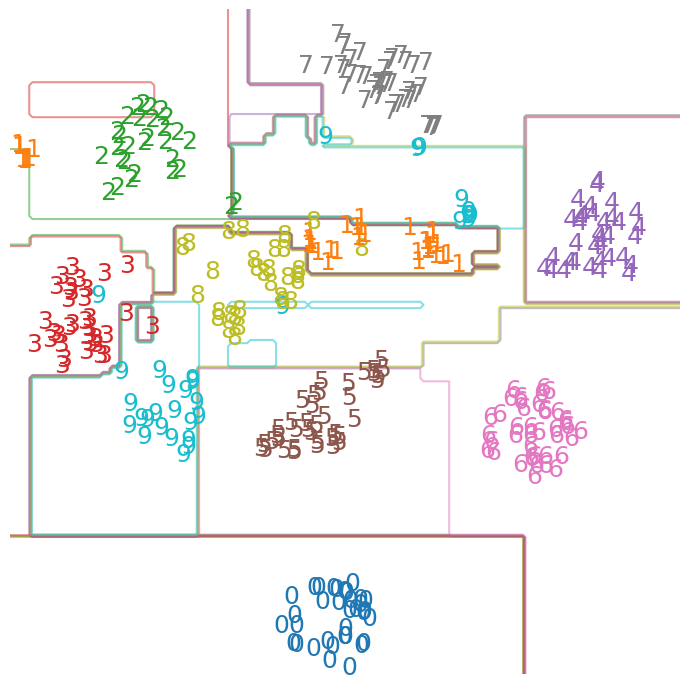

In [29]:
xMin, xMax = Xemb[:, 0].min(), Xemb[:, 0].max() + 0.05
yMin, yMax = Xemb[:, 1].min(), Xemb[:, 1].max() + 0.05
xMesh, yMesh = np.meshgrid(np.arange(xMin, xMax, 0.005),
                           np.arange(yMin, yMax, 0.005))

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 7))
zMesh = search.best_estimator_.predict(np.c_[xMesh.ravel(), yMesh.ravel()])
zMesh = zMesh.reshape(xMesh.shape) * 1.0

# Plot decision regions as colored contour lines
boundary = ax.contour(xMesh, yMesh, zMesh,
                      np.array([-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
                      cmap=plt.cm.tab10, alpha=0.5)

np.random.seed(13)
for i in range(Xemb.shape[0]):
    if np.random.ranf() < 0.8:
        continue
    plt.text(Xemb[i, 0], Xemb[i, 1], str(y[i]),
             color=plt.cm.tab10(y[i] / 10.),
             fontdict={'size': 18})

ax.axis('off')
fig.tight_layout()
plt.show()


The decision boundary plot reveals the geometric structure AdaBoost has carved out of the t-SNE plane. Each colored region corresponds to one digit class; the contour lines are where the model's prediction switches.

Notice three things:

**1. The regions are *piecewise rectangular*.** Even with 500 weak learners, the boundaries look segmented and stepped, not smooth. This is the geometric signature of axis-parallel decision trees -- every cut is either horizontal or vertical, and the union of $T = 500$ such cuts can only produce a piecewise-axis-parallel boundary. A neural network or kernel SVM would produce smooth, curved boundaries instead.

**2. Cluster boundaries are tight, not diffuse.** Where two digit clouds touch (3-5, 8-9, 1-7), the boundary runs cleanly between them. AdaBoost has learned to distinguish these cases without obvious overshoot into the wrong cluster -- thanks in large part to the depth-2 base estimators, which can capture two-feature interactions in a single weak learner.

**3. The model has high local confidence almost everywhere.** Each colored region is tightly bounded and consistent. There are no large "no-man's-land" zones where the model is uncertain. This is *good* if the test data follows the same distribution, but a *risk* if a test point lands far from any training cluster -- the model will still emit a confident prediction. In production, complementing AdaBoost's hard predictions with a calibrated uncertainty estimate (e.g., bootstrap variance, conformal prediction) is often worth the extra effort.

**Cross-chapter connection.** Compare these piecewise-axis-parallel regions with the smooth boundaries we saw in Section 4.2's moons example. The qualitative behavior is the same -- AdaBoost approximates complex boundaries by summing many simple ones -- but with depth-2 base estimators on 10 classes, the complexity has scaled up dramatically. This scaling is what makes AdaBoost a serious classifier rather than a toy. In Chapter 5 (Gradient Boosting), we will see how to push the same idea further by replacing the discrete weak-learner weights $\alpha_t$ with **gradient-based** updates that are smoother and more flexible.


## 4.5 LogitBoost: Boosting with the logistic loss

We close this chapter with a second boosting algorithm: **LogitBoost** (Friedman, Hastie, and Tibshirani, 2000). The motivation is theoretical and practical at once.

**Theoretical.** AdaBoost can be derived as the algorithm that minimizes the **exponential loss**:

$$\mathcal{L}_{\exp}(y, F(\mathbf{x})) = e^{-y \, F(\mathbf{x})}.$$

The weight update $D_i^{t+1} = D_i^t \, e^{-\alpha_t y_i h_t(\mathbf{x}_i)}$ falls out directly from minimizing $\sum_i \mathcal{L}_{\exp}(y_i, F_t(\mathbf{x}_i))$ at each step. Once you see this connection, an obvious question presents itself: *what if we use a different loss?*

**Practical.** The exponential loss penalizes misclassified examples *very* harshly. A misclassified point with margin $-1$ has loss $e^1 \approx 2.72$; a point with margin $-2$ has loss $e^2 \approx 7.39$; margin $-3$ has loss $e^3 \approx 20.09$. The penalty grows exponentially with the distance from the decision boundary. This is why AdaBoost is so sensitive to outliers (Section 4.3): a single far-from-boundary mistake produces a mountain of loss, dragging subsequent weak learners toward fixing it.

The **logistic loss**, by contrast, grows roughly *linearly* in the margin for badly misclassified points:

$$\mathcal{L}_{\log}(y, F(\mathbf{x})) = \log\!\left(1 + e^{-y F(\mathbf{x})}\right).$$

For large negative margins, $\mathcal{L}_{\log} \approx -y F(\mathbf{x})$. This bounded growth makes logistic loss far more robust to outliers. LogitBoost trades AdaBoost's aggressive convergence for resilience -- often the right tradeoff on noisy real-world data.

### 4.5.1 Logistic vs. exponential loss

The plot below makes the contrast explicit.


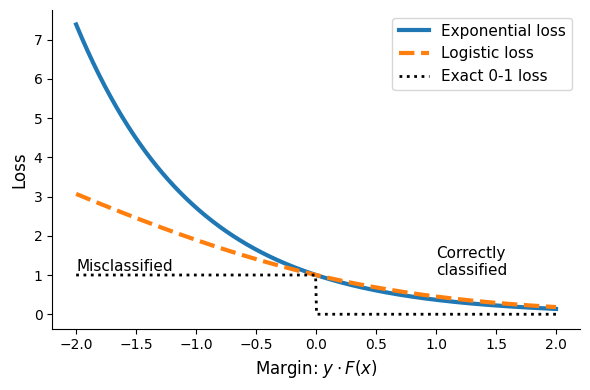

In [30]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

x = np.linspace(-2.0, 2.0, num=500)
ax.plot(x, np.exp(-x), linewidth=3, label='Exponential loss')
ax.plot(x, np.log(1 + np.exp(-x)) / np.log(2), linewidth=3,
        linestyle='--', label='Logistic loss')
ax.plot(x, (-x >= 0).astype(float), linewidth=2, linestyle=':',
        c='k', label='Exact 0-1 loss')

ax.text(-2, 1.1, 'Misclassified', fontsize=11)
ax.text(1, 1, 'Correctly\nclassified', fontsize=11)
ax.set_xlabel('Margin: $y \\cdot F(x)$', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
fig.tight_layout()
plt.show()


The plot shows the three loss functions on the same axes, parameterized by the **margin** $y \cdot F(\mathbf{x})$. Positive margins mean correct classification with confidence; negative margins mean misclassification.

The differences are stark in the misclassified region (left half):

- At margin $-1$: exponential loss is $e \approx 2.72$, logistic loss is $\log(1 + e) / \log 2 \approx 1.94$. Comparable.
- At margin $-2$: exponential loss is $e^2 \approx 7.39$, logistic loss is $\log(1 + e^2) / \log 2 \approx 3.13$. Exponential is now $2.4\times$ logistic.
- Were we to extend to margin $-5$: exponential loss is $e^5 \approx 148$, logistic loss is only $\approx 7.21$. Exponential is **20$\times$ logistic** at this point.

In the correctly-classified region (right half) both losses go to zero as margin grows, with logistic decaying slightly slower. **Both are valid surrogates** for the 0-1 loss in the sense that minimizing them tends to minimize 0-1 error, but they make very different statements about *how badly* a misclassification should be punished.

**The practical consequence.** On a clean dataset, exponential and logistic loss converge to similar solutions. On a dataset with even modest noise, the logistic loss produces ensembles whose decision boundaries are less twisted by outliers, because the "scream" of any single misclassified point is bounded.

This is the core insight that motivated **gradient boosting** (Chapter 5): once you decouple the boosting framework from the exponential loss, you can use *any* differentiable loss function. Squared error for regression. Huber loss for robust regression. Quantile loss for prediction intervals. LogitBoost is the first concrete instance of this generalization.


### 4.5.2 Implementing LogitBoost

LogitBoost differs from AdaBoost in three structural ways:

**1. It works with probabilities, not predictions.** AdaBoost's weak learners output $\pm 1$. LogitBoost's weak learners output a real-valued correction term that is added to a running margin $F_t(\mathbf{x})$, which is then converted to a probability via the sigmoid:

$$P(y = 1 \mid \mathbf{x}) = \frac{1}{1 + e^{-F_t(\mathbf{x})}}.$$

**2. The base learner is a regressor, not a classifier.** Because we are now fitting real-valued residuals, the base estimator must produce real-valued outputs. We use **decision tree regressors** with `max_depth=1` -- regression stumps.

**3. The labels are $\{0, 1\}$ rather than $\{-1, +1\}$.** Probabilities live in $[0, 1]$, so we revert to the natural binary encoding.

The algorithm at iteration $t$:

1. Compute the **working response** -- a Newton-step direction toward the true label:
$$z_i = \frac{y_i - P_i}{P_i (1 - P_i)}$$
2. Compute weights based on prediction confidence:
$$D_i = P_i (1 - P_i)$$
3. Train a regression stump $h_t(\mathbf{x})$ on $(\mathbf{x}_i, z_i, D_i)$.
4. Update the ensemble margin: $F_{t+1}(\mathbf{x}) = F_t(\mathbf{x}) + h_t(\mathbf{x})$.
5. Update probabilities: $P_i = \sigma(F_{t+1}(\mathbf{x}_i))$.

The weight $D_i = P_i (1 - P_i)$ deserves a moment's attention. It is maximized at $P_i = 0.5$ -- exactly when the model is *most uncertain* about example $i$. Confidently classified examples (probability near 0 or 1) get small weights and the next stump ignores them; uncertain examples get large weights and the next stump focuses there. This is a natural notion of "what's hard right now," and it is *bounded* (peaks at $0.25$), unlike AdaBoost's exponential weight blowup.

**Listing 4.5 -- LogitBoost training.**


In [31]:
from sklearn.tree import DecisionTreeRegressor
from scipy.special import expit  # numerically stable sigmoid

# Train a LogitBoost ensemble of regression stumps on labels in {0, 1}.
def fit_logitboosting(X, y, n_estimators=10):
    n_samples, n_features = X.shape
    p = np.full((n_samples,), 0.5)              # initial probability = 0.5 everywhere
    estimators = []

    for t in range(n_estimators):
        # 1. working response: Newton step toward the true label
        z = (y - p) / (p * (1 - p))
        # 2. weights peak at p = 0.5 (maximum uncertainty)
        D = p * (1 - p)

        # 3. fit regression stump to weighted residuals
        h = DecisionTreeRegressor(max_depth=1, random_state=13)
        h.fit(X, z, sample_weight=D)
        estimators.append(h)

        # 4. update running margin F(x) = sum_t h_t(x)
        if t == 0:
            margin = h.predict(X)
        else:
            margin = np.sum(np.array([h.predict(X) for h in estimators]), axis=0)

        # 5. update probabilities via sigmoid
        p = expit(margin)

    return estimators


**Listing 4.6 -- LogitBoost prediction.** Like AdaBoost, predictions sum the contributions of all weak learners; unlike AdaBoost, there are no $\alpha_t$ weights -- each regression stump contributes its raw output. We convert the resulting margin to a $\{0, 1\}$ label via a sign threshold.


In [32]:
# Predict 0/1 labels using a LogitBoost ensemble.
def predict_logit_boosting(X, estimators):
    pred = np.zeros((X.shape[0],))
    for h in estimators:
        pred += h.predict(X)
    return (np.sign(pred) + 1) / 2          # map sign to {0, 1}


**Visualizing the LogitBoost ensemble's evolution.** As with AdaBoost in Section 4.2.2, we plot the boundary at iterations 1, 2, 5, 10, 15, and 20 on the noisy moons dataset. Compare these panels with the AdaBoost evolution figure -- the geometric shapes are similar (axis-parallel cuts adding up), but the convergence behavior differs.


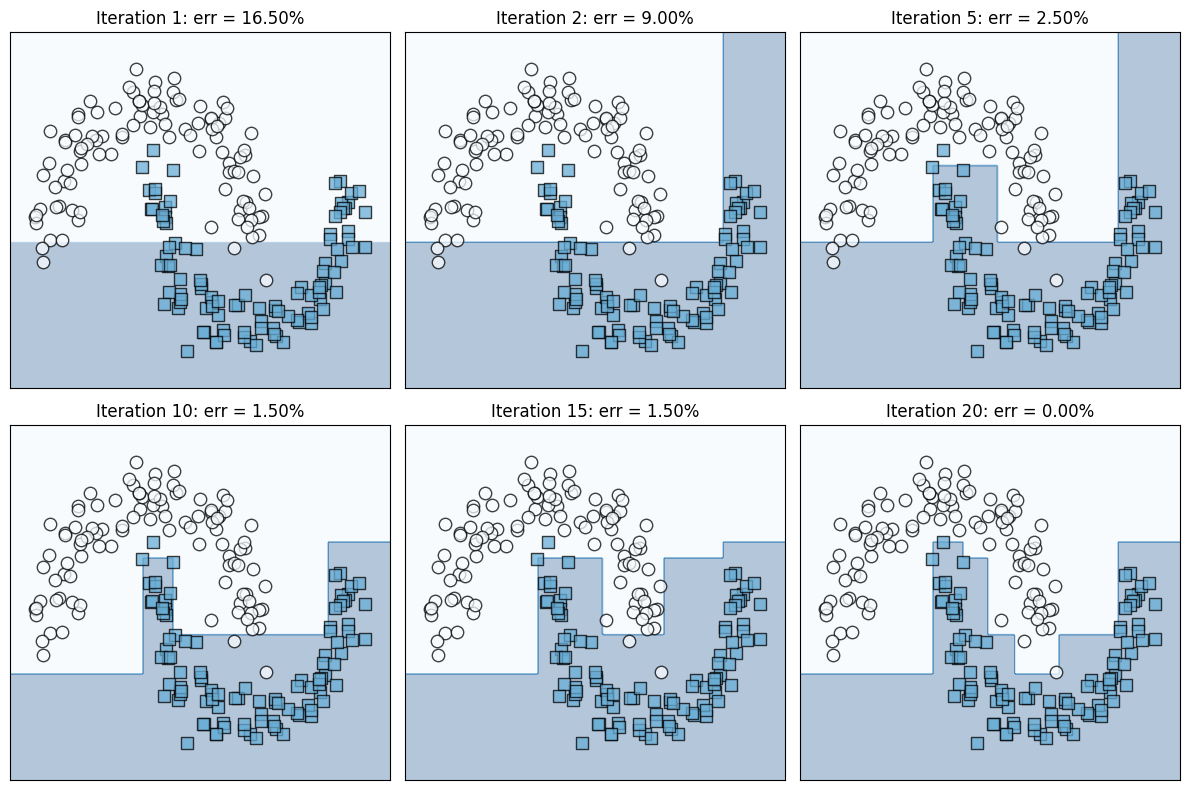

In [33]:
X, y = make_moons(n_samples=200, noise=0.125, random_state=13)

n_samples, n_features = X.shape
n_estimators = 20
p = np.full((n_samples,), 0.5)
estimators = []

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
ax_index = -1

for t in range(n_estimators):
    z = (y - p) / (p * (1 - p))
    D = p * (1 - p)

    h = DecisionTreeRegressor(max_depth=1, random_state=13)
    h.fit(X, z, sample_weight=D)
    estimators.append(h)

    if t == 0:
        margin = h.predict(X)
    else:
        margin = np.sum(np.array([h.predict(X) for h in estimators]), axis=0)
    p = expit(margin)

    if t in [0, 1, 4, 9, 14, 19]:
        ax_index += 1
        r, c = np.divmod(ax_index, 3)
        ypred = predict_logit_boosting(X, estimators)
        err = (1 - accuracy_score(y, ypred)) * 100
        title = 'Iteration {0}: err = {1:4.2f}%'.format(t + 1, err)
        plot_2d_classifier(ax[r, c], X, y,
                           predict_function=predict_logit_boosting,
                           predict_args=estimators,
                           alpha=0.3, xlabel=None, ylabel=None, s=80,
                           title=title, colormap='Blues')
        ax[r, c].set_xticks([]); ax[r, c].set_yticks([])

fig.tight_layout()
plt.show()


The LogitBoost progression parallels AdaBoost's almost exactly:

| Iteration | LogitBoost err | AdaBoost err (Sec 4.2.2) |
|---|---|---|
| 1 | 16.50% | 16.50% |
| 2 | 9.00% | (8.00% at iter 3) |
| 5 | 2.50% | 8.00% |
| 10 | 1.50% | 2.50% |
| 15 | 1.50% | 1.00% |
| 20 | 0.00% | 0.00% |

Both algorithms drive training error to 0% on this clean dataset by iteration 20. **LogitBoost actually converges faster in the early iterations** -- by iteration 5 it has already reached 2.5% error, while AdaBoost is still at 8% at the same iteration count. This is because the working response $z_i = (y_i - P_i) / (P_i(1 - P_i))$ is a Newton-step direction in probability space, which is information-theoretically optimal for the logistic objective.

**Where LogitBoost shines: noisy data.** The two algorithms behave similarly on this clean moons data, but on data with mislabeled examples or true outliers, the picture changes. The bounded growth of the logistic loss means that a single misclassified outlier produces a bounded weight $D_i = P_i(1 - P_i) \leq 0.25$ -- regardless of how badly wrong the model currently is. AdaBoost has no such bound; we saw in Section 4.3 that a single outlier could grow to dominate the training set.

**Where AdaBoost shines: clean, well-separable data.** The aggressive exponential penalty drives faster convergence in the absence of noise, and AdaBoost's $\alpha_t$ weights provide a built-in importance ranking of weak learners that LogitBoost lacks (every regression stump in LogitBoost contributes equally to the margin sum).

**Cross-chapter connection.** LogitBoost is the conceptual bridge to **gradient boosting** (Chapter 5). The Newton-step working response $z_i$ is essentially the negative gradient of the logistic loss at the current prediction. Once you see this -- "boosting is gradient descent in function space" -- you can swap the logistic loss for any differentiable loss and instantly have a working algorithm. That insight underlies XGBoost, LightGBM, and CatBoost, which power many modern tabular ML systems. The road from AdaBoost (1995) to XGBoost (2014) is paved with a single change: from exponential loss, to logistic loss, to *any* loss with a gradient.


## Summary

We covered a lot of ground. The takeaways:

**Sequential ensembles are different from parallel ensembles.** Bagging trains independent strong learners; boosting trains *dependent weak learners*, each one fixing the previous one's mistakes. The two approaches reduce different parts of the bias-variance tradeoff: bagging reduces variance, boosting reduces bias.

**AdaBoost in three formulas.** The whole algorithm is:
$$\alpha_t = \tfrac{1}{2}\log\frac{1 - \epsilon_t}{\epsilon_t}, \qquad D_i^{t+1} = D_i^t \, e^{-\alpha_t y_i h_t(\mathbf{x}_i)}, \qquad H(\mathbf{x}) = \operatorname{sign}\!\sum_t \alpha_t h_t(\mathbf{x}).$$
The $\alpha_t$ formula minimizes exponential loss at each iteration; the $D_i$ update redirects the next weak learner toward currently-misclassified examples; the final prediction is a weighted sign-vote.

**AdaBoost is sensitive to outliers.** The exponential loss penalizes mistakes very harshly, and a single outlier can have its weight grow to dominate the training set. We saw this happen on the moons-with-outlier dataset, where the outlier ended up with $\sim 9\times$ the weight of an average example after 20 iterations.

**Two practical defenses: shrinkage and early stopping.** A learning rate $\eta < 1$ shrinks each weak learner's contribution, slowing the weight blowup that outliers cause. Early stopping caps `n_estimators` to prevent over-training. Both should be tuned via cross-validation; we found `learning_rate=0.8` and `n_estimators=35` were near-optimal on breast cancer.

**Real-world performance.** On the 10-class digit recognition task with t-SNE preprocessing, joint grid search produced an AdaBoost ensemble of 500 depth-2 trees that achieved 97.22% test accuracy. Per-class analysis via the classification report and confusion matrix isolated the hardest digits (3, 8) and the most common confusion pair (8 -> 9).

**LogitBoost trades convergence speed for robustness.** By minimizing the logistic loss instead of the exponential loss, LogitBoost bounds the influence of any single misclassified point. This is the conceptual stepping stone to gradient boosting (Chapter 5), where the loss function becomes a free choice rather than a fixed property of the algorithm.

**What's next.** Chapter 5 introduces **gradient boosting**, which generalizes the LogitBoost idea: instead of fitting a Newton-step working response, fit the negative gradient of an arbitrary differentiable loss. Chapter 6 covers **Newton boosting** (XGBoost-style second-order optimization), and Chapter 7 covers **stochastic gradient boosting** with row and column subsampling. By the end of Part II, the entire tree-boosting hierarchy will be visible from this same framework we built in this chapter.
